**Global Supply Chain Risk & Disruption Analysis** - Phân tích rủi ro và gián đoạn chuỗi cung ứng toàn cầu

Global supply chains are increasingly exposed to operational and external risks such as geopolitical instability, adverse weather conditions, transportation constraints, and variations in carrier performance. These factors can increase shipment lead times and cause supply chain disruptions.

This case study analyzes a simulated dataset of **5,000 international shipments between January 1, 2024 and December 31, 2025** to identify the major factors associated with shipment delays and disruptions.

The analysis focuses on logistics characteristics, environmental conditions, geopolitical risk, and carrier reliability in order to support better supply chain risk management decisions.

1. Business Task

**How can a global logistics company identify high-risk shipment conditions and reduce supply chain disruptions and excessive lead times?**

The analysis aims to:
- Identify the main drivers of shipment disruptions;
determine which shipment conditions are associated with longer lead times;
- Identify high-risk transportation modes, routes, weather conditions, and product categories;
- Examine whether combinations of risk factors create particularly high disruption rates;
- Recommend practical actions to improve supply chain resilience.

2. Stakeholders

The main stakeholders for this analysis are:

- Head of Supply Chain
- Logistics Manager
- Supply Chain Risk Manager
- Carrier Management / Procurement Team

3. Dataset Overview

The dataset contains **5,000 shipment records and 14 variables.**

**Shipment information**
- Shipment_ID
- Date
- Origin_Port
- Destination_Port
- Transport_Mode
- Product_Category
- Distance_km
- Weight_MT

**External and operational risk factors**
- Fuel_Price_Index
- Geopolitical_Risk_Score
- Weather_Condition
- Carrier_Reliability_Score

**Outcome variables**
- Lead_Time_Days
- Disruption_Occurred

The dataset covers:
- 8 origin ports
- 9 destination ports
- 4 transportation modes: Air, Sea, Rail, Road
- 5 product categories: Automotive, Electronics, Perishables, Pharmaceuticals, Textiles
- 5 weather conditions: Clear, Fog, Rain, Storm, Hurricane

    **Dataset limitation:** The dataset is simulated rather than collected from actual company operations. Therefore, findings should be interpreted as analytical insights from the simulated environment rather than evidence about real-world logistics performance.

4. Initial Data Quality Assessment

The first data quality check identified:

- 5,000 rows
- 14 columns
- 0 missing values
- 0 duplicate rows
- 0 duplicate Shipment IDs

The ***Date*** variable is initially stored as text and should be converted to a datetime format before time-based analysis.

No records should be removed at this stage because there is currently no evidence that any observation is invalid.

5. Initial Performance Baseline

Before performing detailed analysis, several overall metrics were calculated.

The large difference between the **average lead time (19.36 days)** and the **median lead time (8.25 days)** suggests that the lead-time distribution may contain a long right tail.

Therefore, later analysis should consider:

- Mean lead time;
- Median lead time;
- Lead-time distribution;
- Extreme lead-time observations;
- Percentile measures such as P95.

Using only the mean could provide a misleading picture of typical shipment performance.

6. Key Business Questions

The analysis will investigate the following questions.

**Q1. What is the overall level of supply chain disruption?**
- What percentage of shipments are disrupted?
- Does disruption change over time?

**Q2. Which transportation modes have the highest disruption rates and longest lead times?**

**Q3. How does geopolitical risk affect supply chain performance?**

**Q4. How do weather conditions affect disruption and lead time?**

**Q5. Does carrier reliability reduce disruption risk?**

**Q6. Which routes or ports represent the highest supply chain risk?**

Analyze performance by:

- Origin port;
- Destination port;
- Origin–destination route.

**Q7. Are some product categories more vulnerable to disruption?**

**Q8. Is there a risk “tipping point”?**

Investigate whether combinations of factors such as: ***High geopolitical risk + adverse weather + low carrier reliability***
produce a disproportionately high disruption rate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026/global_supply_chain_risk_2026.csv")

In [2]:
#DATA CLEANING
df.head()
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()
df["Shipment_ID"].duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

np.int64(0)

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].min(), df["Date"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [4]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Year_Month"] = df["Date"].dt.to_period("M")

In [5]:
#EDA 1
df["Lead_Time_Days"].describe()

count    5000.000000
mean       19.355386
std        31.405143
min         0.500000
25%         2.110000
50%         8.245000
75%        21.207500
max       236.390000
Name: Lead_Time_Days, dtype: float64

In [6]:
df["Lead_Time_Days"].quantile([0.90, 0.95, 0.99])

0.90     51.5250
0.95     80.8115
0.99    169.8592
Name: Lead_Time_Days, dtype: float64

In [7]:
df["Lead_Time_Days"].skew()

np.float64(3.349222712647645)

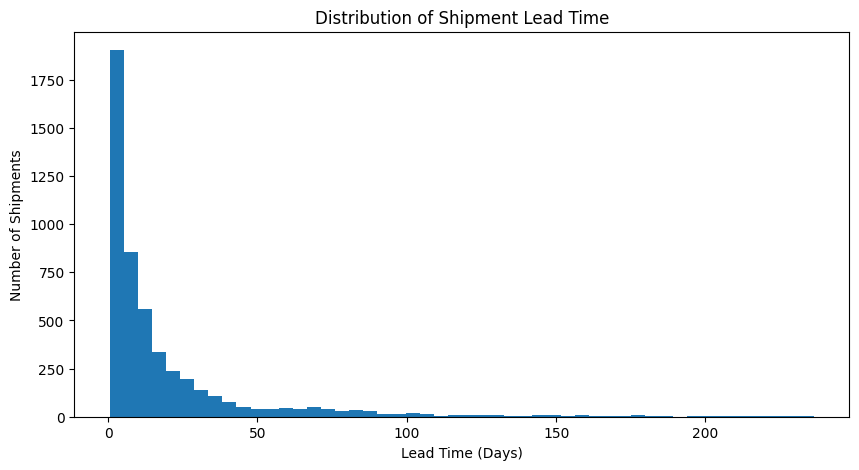

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["Lead_Time_Days"],
    bins=50
)
plt.title("Distribution of Shipment Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Shipments")
plt.show()

1. Lead Time Distribution

Shipment lead time is highly right-skewed. The mean lead time is more than twice the median, while the 95th percentile reaches approximately 81 days. This indicates that most shipments have relatively moderate lead times, while a smaller group experiences extremely long delays. Therefore, the median and percentile-based metrics should be reported alongside the mean.

In [9]:
df["Disruption_Occurred"].value_counts()

Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

In [10]:
df["Disruption_Occurred"].value_counts(normalize=True) * 100

Disruption_Occurred
1    61.26
0    38.74
Name: proportion, dtype: float64

2. Disruption and Lead Time

Out of 5,000 shipments:

- 3,063 shipments were disrupted
- 1,937 shipments were not disrupted
- Overall disruption rate: **61.26%**

In [11]:
df.groupby("Disruption_Occurred")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Disruption_Occurred,,,,
0,1937,8.885183,6.24,9.926030
1,3063,25.976601,10.69,37.877449


Lead-time performance differs substantially between the two groups. Disrupted shipments therefore have an average lead time approximately **2.9 times** that of non-disrupted shipments.

In [12]:
Q1 = df["Lead_Time_Days"].quantile(0.25)
Q3 = df["Lead_Time_Days"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
upper_bound

lead_time_outliers = df[df["Lead_Time_Days"] > upper_bound]
len(lead_time_outliers)

518

In [13]:
lead_time_outliers["Disruption_Occurred"].value_counts(normalize=True) * 100

Disruption_Occurred
1    96.718147
0     3.281853
Name: proportion, dtype: float64

Using the IQR method, 518 shipments were identified as unusually high lead-time observations. Among these shipments, approximately **96.7% experienced a disruption.**

This suggests that supply chain disruptions are particularly associated with the extreme upper tail of shipment lead times.
> **Supply chain disruptions are not only frequent in the dataset but are also strongly associated with extreme shipment lead times. While the typical shipment has a median lead time of 8.25 days, disrupted shipments average nearly 26 days, and approximately 96.7% of high lead-time outliers experience disruption.**

In [14]:
transport_analysis = (
    df.groupby("Transport_Mode")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

transport_analysis["Disruption_Rate"] *= 100

transport_analysis

,Transport_Mode,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
0,Air,1320,61.742424,1.644273,0.930
1,Rail,1185,61.181435,19.954253,11.540
2,Road,1214,61.037891,16.452306,9.295
3,Sea,1281,61.046058,39.802966,21.790


3. Transportation Mode Analysis

The four transportation modes show very different lead-time profiles. Transportation mode has a major relationship with **lead time**, but surprisingly little relationship with **disruption probability**. All four modes have disruption rates around 61%.

However:

- Air has the shortest average lead time at only **1.64 days.**
- Sea has the longest average lead time at **39.80 days.**
- The P95 lead time for Sea reaches **157.36 days.**

In [15]:
weather_analysis = (
    df.groupby("Weather_Condition")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

weather_analysis["Disruption_Rate"] *= 100

weather_analysis.sort_values("Disruption_Rate",ascending=False)

,Weather_Condition,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
2,Hurricane,990,100.000000,53.501848,40.030
4,Storm,1002,79.540918,19.299182,14.725
1,Fog,1036,48.069498,9.892847,7.000
3,Rain,977,41.965200,7.736049,5.980
0,Clear,995,36.984925,6.698704,5.130


4. Weather Risk Analysis

Weather shows a much stronger relationship with disruptions. There is a clear deterioration in supply chain performance as weather conditions become more severe.

Compared with clear conditions:

- Storms more than double the disruption rate;
- Hurricanes result in disruption for every shipment in the dataset;
- Average lead time during hurricanes reaches **53.5 days.**

Weather is therefore one of the strongest candidate risk factors identified so far.
> Because this is a simulated dataset and every shipment under Hurricane conditions is classified as disrupted, the relationship may partly reflect the rules used to generate the synthetic data.
This needs to be considered later when building predictive models, because a model could achieve artificially high classification performance by relying heavily on the weather variable.

In [16]:
df["Geo_Risk_Quartile"] = pd.qcut(
    df["Geopolitical_Risk_Score"],
    q=4
)
geo_analysis = (
    df.groupby("Geo_Risk_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean")
    )
)

geo_analysis

,Shipments,Disruption_Rate,Avg_Lead_Time
Geo_Risk_Quartile,,,
"(-0.001, 2.6]",1260,0.457937,15.773675
"(2.6, 5.1]",1255,0.588845,18.800255
"(5.1, 7.5]",1256,0.662420,19.537492
"(7.5, 10.0]",1229,0.744508,23.408210


5. Geopolitical Risk Analysis

Rather than defining arbitrary risk categories, geopolitical risk was divided into four data-driven quartiles.

A strong monotonic pattern appears:

> As geopolitical risk increases, disruption rates increase.

The disruption rate rises from **45.8% in the lowest-risk quartile to 74.5% in the highest-risk quartile.** This is approximately a **28.7 percentage-point difference.** Geopolitical risk therefore appears substantially more relevant to disruption than variables such as transport mode.

In [17]:
df["Carrier_Reliability_Quartile"] = pd.qcut(
    df["Carrier_Reliability_Score"],
    q=4
)
carrier_analysis = (
    df.groupby("Carrier_Reliability_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean")
    )
)

carrier_analysis

,Shipments,Disruption_Rate,Avg_Lead_Time
Carrier_Reliability_Quartile,,,
"(0.499, 0.629]",1251,0.650679,19.503429
"(0.629, 0.757]",1257,0.651551,19.431583
"(0.757, 0.879]",1248,0.588942,19.771715
"(0.879, 1.0]",1244,0.558682,18.711849


6. Carrier Reliability Analysis

Carrier reliability also shows a meaningful relationship with disruption probability. Shipments associated with the most reliable carriers have a disruption rate approximately **9 percentage points lower** than shipments in the least reliable groups.

However, carrier reliability has only a weak relationship with lead time itself. This suggests that carrier reliability may be more useful as a **risk-control variable** than as a direct predictor of transportation duration.

In [18]:
risk_interaction = (
    df
    .groupby(["Weather_Condition", "Geo_Risk_Quartile"],observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean")
    )
    .reset_index()
)

risk_interaction["Disruption_Rate"] *= 100

risk_interaction

,Weather_Condition,Geo_Risk_Quartile,Shipments,Disruption_Rate
0,Clear,"(-0.001, 2.6]",259,19.691120
1,Clear,"(2.6, 5.1]",245,35.918367
2,Clear,"(5.1, 7.5]",256,42.578125
3,Clear,"(7.5, 10.0]",235,51.063830
4,Fog,"(-0.001, 2.6]",253,29.249012
5,Fog,"(2.6, 5.1]",265,41.132075
6,Fog,"(5.1, 7.5]",262,54.580153
7,Fog,"(7.5, 10.0]",256,67.187500
8,Hurricane,"(-0.001, 2.6]",246,100.000000
9,Hurricane,"(2.6, 5.1]",257,100.000000


7. Testing the Risk “Tipping Point”

One of the main objectives of the case study is to determine whether combinations of risks create disproportionately high disruption probabilities.

Geopolitical risk was therefore analyzed together with weather conditions.

> Neither geopolitical risk nor moderate weather conditions alone necessarily imply near-certain disruption.
However, when both conditions deteriorate, disruption probability rises sharply.

The analysis therefore provides preliminary evidence of a possible risk interaction:

> External risks may compound rather than operate independently.

The strongest non-hurricane risk condition identified so far is:
**Storm + geopolitical risk score in the highest quartile** with a disruption rate of approximately **95.9%.**

However, this should currently be described as an **observed interaction pattern**, not a statistically proven tipping point. A later logistic regression or interaction analysis will be required to test whether the combined effect is statistically meaningful.

In [19]:
df[["Distance_km", "Lead_Time_Days"]].corr()

,Distance_km,Lead_Time_Days
Distance_km,1.000000,0.335665
Lead_Time_Days,0.335665,1.000000


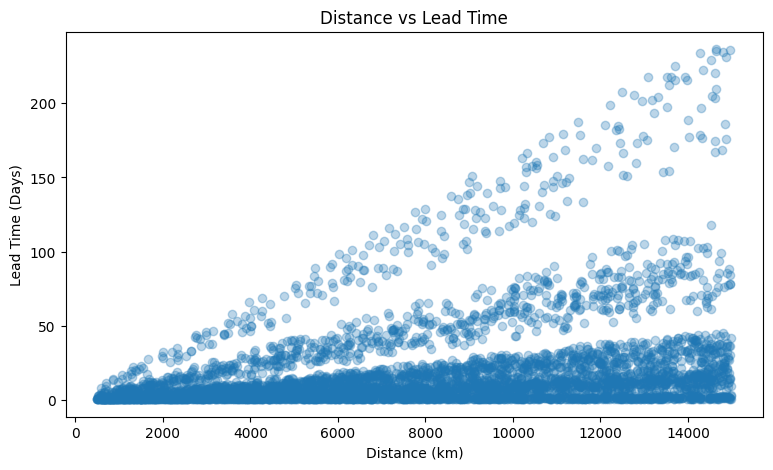

In [20]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["Distance_km"],
    df["Lead_Time_Days"],
    alpha=0.3
)

plt.title("Distance vs Lead Time")
plt.xlabel("Distance (km)")
plt.ylabel("Lead Time (Days)")

plt.show()

In [21]:
#Do different product categories actually experience 
#different disruption rates?
product_analysis = (
    df.groupby("Product_Category")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

product_analysis["Disruption_Rate"] *= 100

product_analysis.sort_values("Disruption_Rate",ascending=False)

,Product_Category,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
4,Textiles,1010,64.851485,20.096733,8.350
3,Pharmaceuticals,1006,61.133201,19.795736,8.865
0,Automotive,959,60.479666,18.980938,7.720
2,Perishables,1009,60.257681,20.131685,8.170
1,Electronics,1016,59.547244,17.764892,7.995


> Product category does not appear to meaningfully differentiate disruption risk.

In [22]:
#Which origin ports have the highest disruption rates?
origin_analysis = (
    df.groupby("Origin_Port")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

origin_analysis["Disruption_Rate"] *= 100

origin_analysis.sort_values("Disruption_Rate",ascending=False)

,Origin_Port,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
3,Hamburg,597,62.479062,20.071692,8.680
6,Shanghai,644,62.422360,21.361972,9.215
7,Singapore,599,62.270451,18.978781,7.880
0,Antwerp,635,61.417323,18.949795,8.310
2,Dubai,610,60.819672,17.011213,8.055
4,Los Angeles,602,60.299003,17.616113,7.375
1,Busan,667,60.269865,19.607976,8.200
5,Rotterdam,646,60.216718,21.014474,8.495


In [23]:
#Are some destination ports consistently associated with 
#higher disruption rates or longer lead times?
destination_analysis = (
    df.groupby("Destination_Port")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

destination_analysis["Disruption_Rate"] *= 100

destination_analysis.sort_values("Disruption_Rate",ascending=False)

,Destination_Port,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
8,Singapore,528,63.257576,20.828106,8.030
5,Marseille,583,62.264151,20.761647,8.920
1,Busan,570,62.105263,21.660211,9.120
7,Shanghai,561,61.853832,18.572674,8.150
0,Antwerp,552,61.413043,17.805616,8.000
3,Hamburg,536,61.007463,19.037612,9.065
6,Rotterdam,574,60.627178,18.795087,7.250
4,Los Angeles,537,59.776536,18.886276,8.010
2,Dubai,559,59.033989,17.794079,7.930


In [24]:
#Which trade lanes have the highest disruption rates and longest lead times?
df["Route"] = (df["Origin_Port"] + " → " + df["Destination_Port"])

route_analysis = (
    df.groupby("Route")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

route_analysis["Disruption_Rate"] *= 100

route_analysis.sort_values("Disruption_Rate",ascending=False).head(10)

,Route,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
45,Rotterdam → Marseille,68,75.000000,27.762353,10.325
39,Los Angeles → Singapore,68,72.058824,20.739412,7.345
29,Hamburg → Rotterdam,72,70.833333,24.670694,13.785
41,Rotterdam → Busan,86,68.604651,30.366163,13.140
14,Busan → Shanghai,91,68.131868,19.167582,11.210
56,Singapore → Antwerp,72,68.055556,18.344722,7.405
55,Shanghai → Singapore,62,67.741935,23.230484,8.540
12,Busan → Marseille,65,67.692308,28.813538,7.760
27,Hamburg → Los Angeles,85,67.058824,23.889765,9.750
53,Shanghai → Marseille,77,66.233766,26.584416,9.190


In [25]:
#Check the route sample size
route_analysis_filtered = route_analysis[
    route_analysis["Shipments"] >= 30
]

route_analysis_filtered.sort_values(
    "Disruption_Rate",ascending=False).head(10)

,Route,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
45,Rotterdam → Marseille,68,75.000000,27.762353,10.325
39,Los Angeles → Singapore,68,72.058824,20.739412,7.345
29,Hamburg → Rotterdam,72,70.833333,24.670694,13.785
41,Rotterdam → Busan,86,68.604651,30.366163,13.140
14,Busan → Shanghai,91,68.131868,19.167582,11.210
56,Singapore → Antwerp,72,68.055556,18.344722,7.405
55,Shanghai → Singapore,62,67.741935,23.230484,8.540
12,Busan → Marseille,65,67.692308,28.813538,7.760
27,Hamburg → Los Angeles,85,67.058824,23.889765,9.750
53,Shanghai → Marseille,77,66.233766,26.584416,9.190


In [26]:
#Fuel Price → Disruption / Lead Time
df["Fuel_Price_Quartile"] = pd.qcut(
    df["Fuel_Price_Index"],
    q=4,
    labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)
fuel_analysis = (
    df
    .groupby("Fuel_Price_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean")
    )
    .reset_index()
)

fuel_analysis["Disruption_Rate"] *= 100

fuel_analysis

,Fuel_Price_Quartile,Shipments,Disruption_Rate,Avg_Lead_Time
0,Q1 Low,1261,61.141951,20.191776
1,Q2,1245,61.445783,19.130691
2,Q3,1254,61.562998,19.163445
3,Q4 High,1240,60.887097,18.924540


> Fuel price does not appear to be an important direct disruption driver in this dataset.

In [27]:
#Do heavier shipments take longer to deliver or experience more disruptions?
df["Weight_Quartile"] = pd.qcut(
    df["Weight_MT"],
    q=4,
    labels=["Q1 Light", "Q2", "Q3", "Q4 Heavy"]
)
weight_analysis = (
    df
    .groupby("Weight_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean")
    )
    .reset_index()
)

weight_analysis["Disruption_Rate"] *= 100

weight_analysis

,Weight_Quartile,Shipments,Disruption_Rate,Avg_Lead_Time
0,Q1 Light,1250,60.24,19.611240
1,Q2,1250,60.96,19.688184
2,Q3,1250,62.40,18.873568
3,Q4 Heavy,1250,61.44,19.248552


In [28]:
#EDA 2
transport_analysis = (
    df.groupby("Transport_Mode")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median"),
          P95_Lead_Time=("Lead_Time_Days", lambda x: x.quantile(0.95))
      )
      .reset_index()
)

transport_analysis["Disruption_Rate"] *= 100

transport_analysis.round(2)

,Transport_Mode,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Air,1320,61.74,1.64,0.93,5.96
1,Rail,1185,61.18,19.95,11.54,75.87
2,Road,1214,61.04,16.45,9.30,64.86
3,Sea,1281,61.05,39.80,21.79,157.36


> Disruption rates are nearly identical across all four transport modes, suggesting that transportation mode alone does not meaningfully differentiate disruption risk in this dataset. Also, lead time is right-skew.

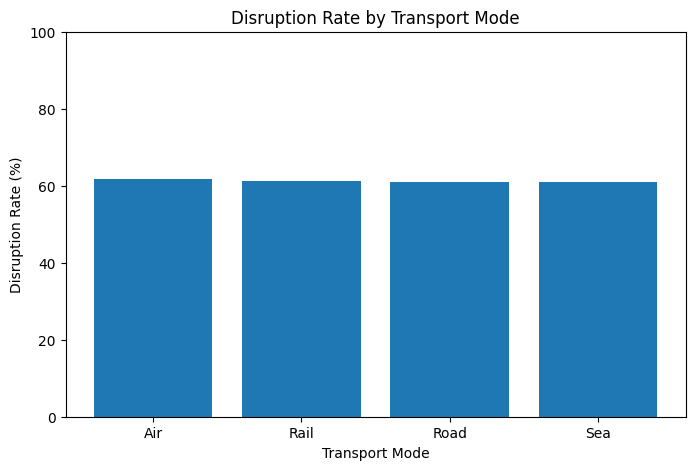

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    transport_analysis["Transport_Mode"],
    transport_analysis["Disruption_Rate"]
)

plt.title("Disruption Rate by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.show()

> Transport mode does not appear to be a major discriminator of disruption occurrence.

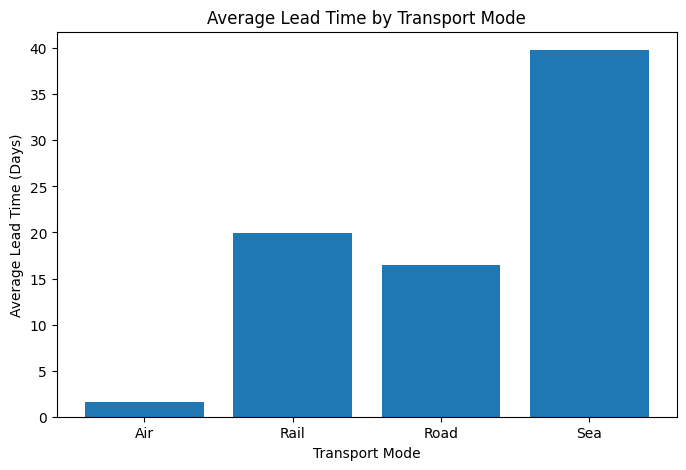

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    transport_analysis["Transport_Mode"],
    transport_analysis["Avg_Lead_Time"]
)

plt.title("Average Lead Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Lead Time (Days)")

plt.show()

> Transportation mode strongly differentiates shipment lead time but has little apparent relationship with disruption frequency. Air shipments have the shortest average lead time at 1.64 days, while Sea shipments average 39.80 days and have a P95 lead time of 157.36 days. However, disruption rates remain approximately 61% across all four transportation modes.

In [31]:
#How do different weather conditions relate to shipment disruption 
#and lead time?
df["Weather_Condition"].value_counts()

Weather_Condition
Fog          1036
Storm        1002
Clear         995
Hurricane     990
Rain          977
Name: count, dtype: int64

In [32]:
weather_analysis = (
    df.groupby("Weather_Condition")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median"),
          P95_Lead_Time=("Lead_Time_Days", lambda x: x.quantile(0.95))
      )
      .reset_index()
)

weather_analysis["Disruption_Rate"] *= 100

weather_analysis.sort_values("Disruption_Rate",ascending=False)

,Weather_Condition,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
2,Hurricane,990,100.000000,53.501848,40.030,170.3560
4,Storm,1002,79.540918,19.299182,14.725,61.3685
1,Fog,1036,48.069498,9.892847,7.000,32.6475
3,Rain,977,41.965200,7.736049,5.980,23.9760
0,Clear,995,36.984925,6.698704,5.130,21.2360


> Weather condition **is strongly associated with** shipment disruption. The disruption rate rises from 37.0% under clear conditions to 79.5% during storms and reaches 100% during hurricanes.

> Hurricane conditions correspond to a 100% disruption rate in the dataset. Because the data are simulated, this perfect relationship may reflect the underlying data-generation rules rather than a pattern that should be expected in real-world supply chains.

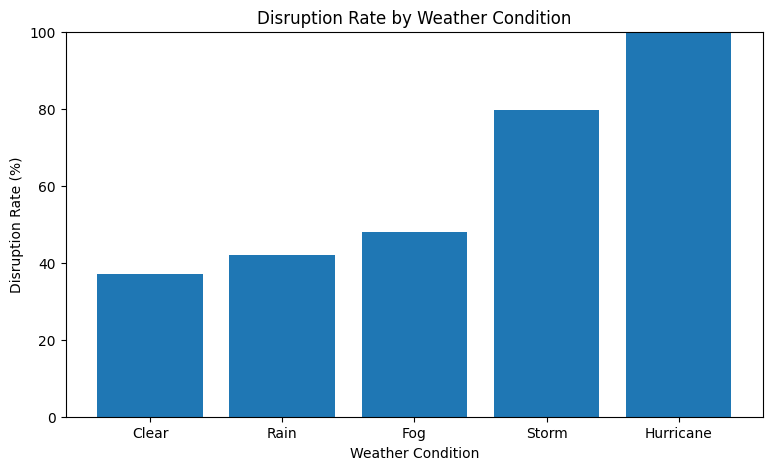

In [33]:
weather_order = [
    "Clear",
    "Rain",
    "Fog",
    "Storm",
    "Hurricane"
]

weather_plot = (
    weather_analysis
    .set_index("Weather_Condition")
    .loc[weather_order]
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    weather_plot["Weather_Condition"],
    weather_plot["Disruption_Rate"]
)

plt.title("Disruption Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.show()

> Disruption risk increases substantially as weather conditions deteriorate, with a particularly sharp increase from Fog to Storm conditions.

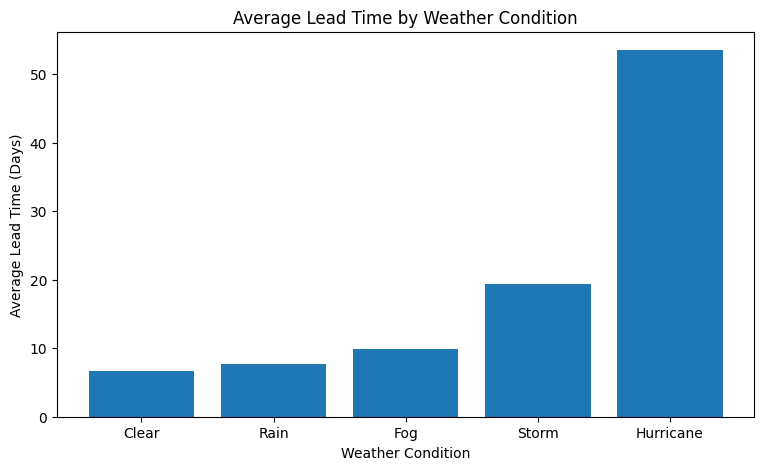

In [34]:
plt.figure(figsize=(9, 5))

plt.bar(
    weather_plot["Weather_Condition"],
    weather_plot["Avg_Lead_Time"]
)

plt.title("Average Lead Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Lead Time (Days)")

plt.show()

> Weather conditions show a strong relationship with both disruption frequency and shipment lead time. Disruption rates increase from 37.0% under clear conditions to 79.5% during storms and 100% during hurricanes. Average lead time similarly increases from 6.7 days under clear conditions to 53.5 days under hurricane conditions, suggesting that adverse weather is associated with both higher disruption exposure and substantially longer shipment duration.
> However, because the dataset is simulated, the perfect 100% disruption rate under hurricane conditions should be interpreted cautiously and may reflect the synthetic data-generation process.

In [35]:
df["Geopolitical_Risk_Score"].describe()

count    5000.000000
mean        5.076900
std         2.877832
min         0.000000
25%         2.600000
50%         5.100000
75%         7.500000
max        10.000000
Name: Geopolitical_Risk_Score, dtype: float64

In [36]:
df["Geo_Risk_Quartile"] = pd.qcut(
    df["Geopolitical_Risk_Score"],
    q=4,
    labels=[
        "Q1 Low",
        "Q2",
        "Q3",
        "Q4 High"
    ]
)

df["Geo_Risk_Quartile"].value_counts().sort_index()

Geo_Risk_Quartile
Q1 Low     1260
Q2         1255
Q3         1256
Q4 High    1229
Name: count, dtype: int64

In [37]:
geo_analysis = (
    df.groupby("Geo_Risk_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        P95_Lead_Time=("Lead_Time_Days",lambda x: x.quantile(0.95)
        )
    )
    .reset_index()
)

geo_analysis["Disruption_Rate"] *= 100

geo_analysis.round(2)

,Geo_Risk_Quartile,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Q1 Low,1260,45.79,15.77,6.72,69.21
1,Q2,1255,58.88,18.80,8.41,75.90
2,Q3,1256,66.24,19.54,8.27,80.24
3,Q4 High,1229,74.45,23.41,10.05,96.57


> The disruption rate increases by approximately 28.7 percentage points from the lowest to the highest geopolitical-risk quartile.
> Higher geopolitical risk is clearly associated with a higher probability of shipment disruption.

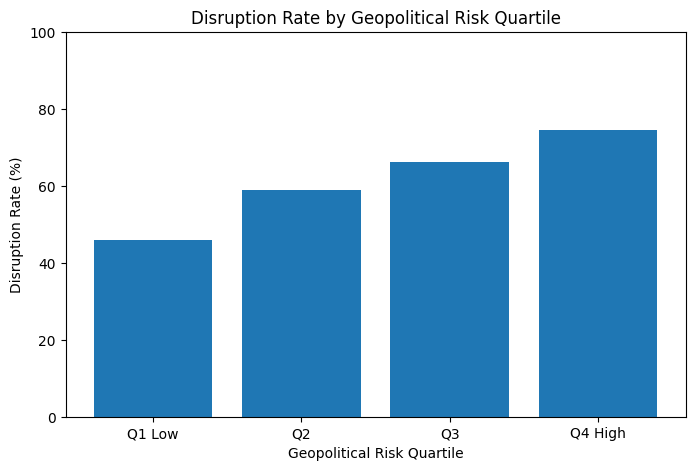

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    geo_analysis["Geo_Risk_Quartile"],
    geo_analysis["Disruption_Rate"]
)

plt.title("Disruption Rate by Geopolitical Risk Quartile")
plt.xlabel("Geopolitical Risk Quartile")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.show()

In [39]:
df[["Geopolitical_Risk_Score","Lead_Time_Days"]].corr()

,Geopolitical_Risk_Score,Lead_Time_Days
Geopolitical_Risk_Score,1.00000,0.08765
Lead_Time_Days,0.08765,1.00000


In [40]:
df.groupby("Disruption_Occurred")["Geopolitical_Risk_Score"].agg(["mean", "median"])

,mean,median
Disruption_Occurred,,
0,4.262158,4.0
1,5.592132,5.8


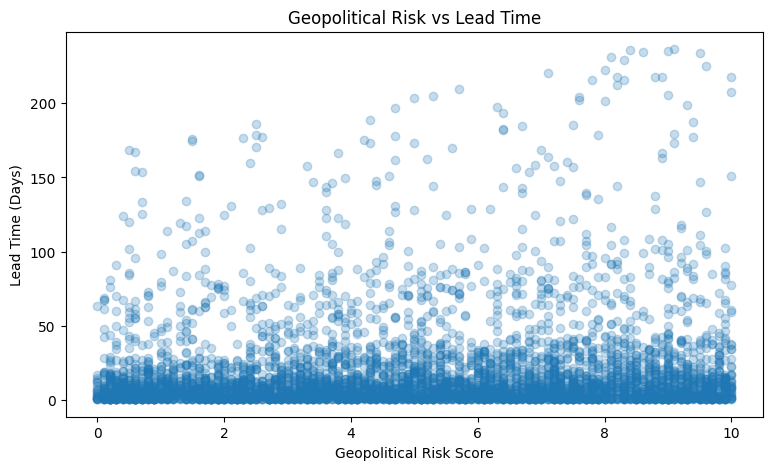

In [41]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["Geopolitical_Risk_Score"],
    df["Lead_Time_Days"],
    alpha=0.25
)

plt.title("Geopolitical Risk vs Lead Time")
plt.xlabel("Geopolitical Risk Score")
plt.ylabel("Lead Time (Days)")

plt.show()

> Geopolitical risk shows a clear positive relationship with shipment disruption. The disruption rate increases consistently from 45.8% among shipments in the lowest geopolitical-risk quartile to 74.5% in the highest quartile, a difference of approximately 28.7 percentage points. Lead time also increases across risk quartiles, although the direct correlation between geopolitical risk and lead time is weak, suggesting that other operational factors play a larger role in determining shipment duration.

In [42]:
df["Carrier_Reliability_Score"].describe()

count    5000.000000
mean        0.754387
std         0.144363
min         0.500000
25%         0.629000
50%         0.757000
75%         0.879000
max         1.000000
Name: Carrier_Reliability_Score, dtype: float64

In [43]:
df["Carrier_Reliability_Quartile"] = pd.qcut(
    df["Carrier_Reliability_Score"],
    q=4,
    labels=[
        "Q1 Low",
        "Q2",
        "Q3",
        "Q4 High"
    ]
)
df["Carrier_Reliability_Quartile"].value_counts().sort_index()

Carrier_Reliability_Quartile
Q1 Low     1251
Q2         1257
Q3         1248
Q4 High    1244
Name: count, dtype: int64

In [44]:
carrier_analysis = (
    df.groupby("Carrier_Reliability_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        P95_Lead_Time=("Lead_Time_Days",lambda x: x.quantile(0.95)
        )
    )
    .reset_index()
)

carrier_analysis["Disruption_Rate"] *= 100

carrier_analysis.round(2)

,Carrier_Reliability_Quartile,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Q1 Low,1251,65.07,19.50,8.40,83.72
1,Q2,1257,65.16,19.43,8.26,79.04
2,Q3,1248,58.89,19.77,8.20,84.70
3,Q4 High,1244,55.87,18.71,8.15,76.18


> Shipments in the highest carrier-reliability quartile have a disruption rate approximately 9.2 percentage points lower than shipments in the lowest-reliability quartile.
> Carrier reliability has a moderate descriptive relationship with disruption.

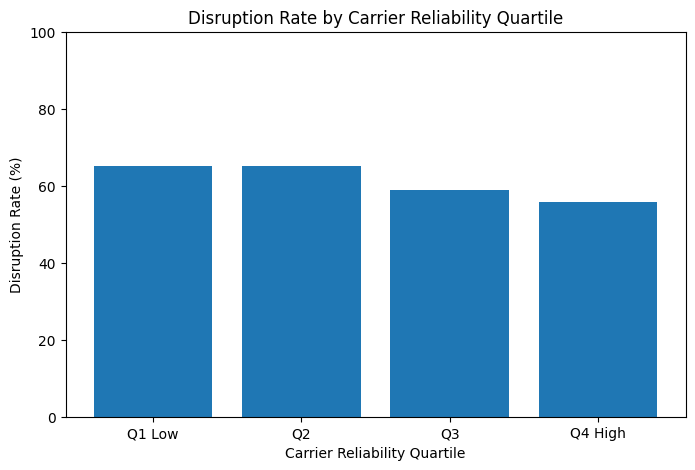

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    carrier_analysis["Carrier_Reliability_Quartile"],
    carrier_analysis["Disruption_Rate"]
)

plt.title("Disruption Rate by Carrier Reliability Quartile")
plt.xlabel("Carrier Reliability Quartile")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.show()

In [46]:
df[["Carrier_Reliability_Score","Lead_Time_Days"]].corr()

,Carrier_Reliability_Score,Lead_Time_Days
Carrier_Reliability_Score,1.000000,-0.008773
Lead_Time_Days,-0.008773,1.000000


> Carrier reliability has virtually no direct linear relationship with lead time in this dataset.

In [47]:
df.groupby("Disruption_Occurred")["Carrier_Reliability_Score"].agg(
    ["mean", "median"]
)

,mean,median
Disruption_Occurred,,
0,0.768714,0.781
1,0.745327,0.741


In [48]:
df[["Carrier_Reliability_Score","Disruption_Occurred"]].corr()

,Carrier_Reliability_Score,Disruption_Occurred
Carrier_Reliability_Score,1.000000,-0.078927
Disruption_Occurred,-0.078927,1.000000


> Carrier reliability is moderately associated with disruption risk but shows almost no relationship with shipment lead time. Shipments in the highest reliability quartile have a disruption rate of 55.9%, compared with 65.1% among those in the lowest quartile, a difference of approximately 9.2 percentage points. In contrast, average and median lead times remain nearly unchanged across reliability groups, suggesting that carrier reliability may be more relevant to shipment continuity than transportation speed.

In [49]:
df["Distance_km"].describe()

count     5000.000000
mean      7704.063888
std       4199.687885
min        500.170000
25%       4036.010000
50%       7750.125000
75%      11347.462500
max      14995.910000
Name: Distance_km, dtype: float64

In [50]:
df[["Distance_km", "Lead_Time_Days"]].corr()

,Distance_km,Lead_Time_Days
Distance_km,1.000000,0.335665
Lead_Time_Days,0.335665,1.000000


> Shipment distance shows a moderate positive relationship with lead time. Longer-distance shipments generally tend to require more time.

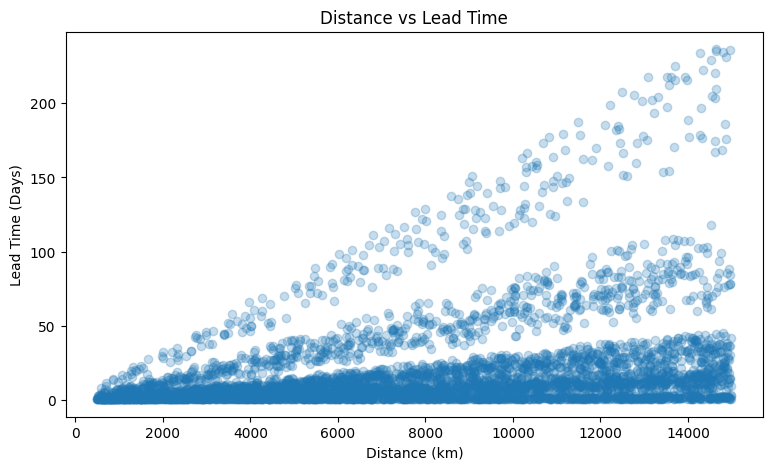

In [51]:
plt.figure(figsize=(9, 5))

plt.scatter(df["Distance_km"],df["Lead_Time_Days"],alpha=0.25)

plt.title("Distance vs Lead Time")
plt.xlabel("Distance (km)")
plt.ylabel("Lead Time (Days)")

plt.show()

In [52]:
df["Distance_Quartile"] = pd.qcut(
    df["Distance_km"],
    q=4,
    labels=[
        "Q1 Short",
        "Q2",
        "Q3",
        "Q4 Long"
    ]
)

distance_analysis = (
    df.groupby("Distance_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Avg_Distance=("Distance_km", "mean"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        P95_Lead_Time=("Lead_Time_Days",lambda x: x.quantile(0.95)
        )
    )
    .reset_index()
)

distance_analysis["Disruption_Rate"] *= 100

distance_analysis.round(2)

,Distance_Quartile,Shipments,Avg_Distance,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Q1 Short,1250,2250.81,60.40,5.70,2.72,21.55
1,Q2,1250,5866.83,61.20,14.63,7.36,52.43
2,Q3,1250,9539.73,62.24,24.62,11.50,113.99
3,Q4 Long,1250,13158.88,61.20,32.48,16.56,108.00


In [53]:
df[["Distance_km", "Disruption_Occurred"]].corr()

,Distance_km,Disruption_Occurred
Distance_km,1.000000,0.009905
Disruption_Occurred,0.009905,1.000000


> Longer distance is associated with longer shipment duration, but not with a meaningfully higher disruption rate.

In [54]:
#Within the same transport mode, does distance still matter?
for mode in df["Transport_Mode"].unique():
    mode_data = df[df["Transport_Mode"] == mode]
    correlation = mode_data[["Distance_km", "Lead_Time_Days"]
                            ].corr().iloc[0, 1]
    print(mode,round(correlation, 3))

Rail 0.452
Air 0.424
Road 0.479
Sea 0.476


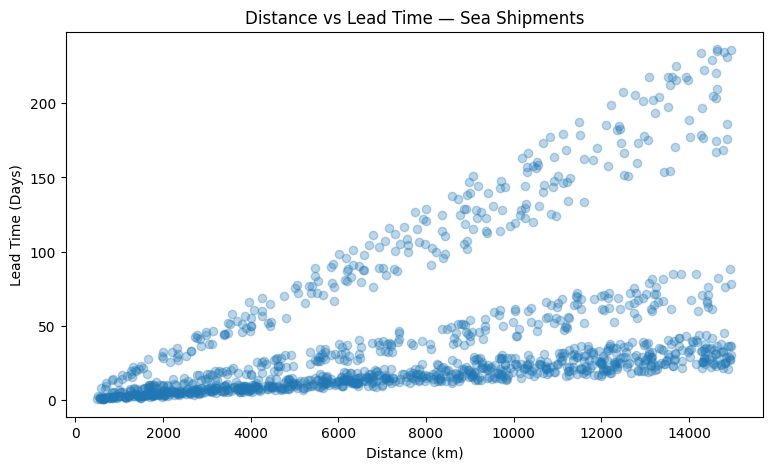

In [55]:
sea_data = df[df["Transport_Mode"] == "Sea"]

plt.figure(figsize=(9, 5))

plt.scatter(sea_data["Distance_km"],sea_data["Lead_Time_Days"],alpha=0.3)

plt.title("Distance vs Lead Time — Sea Shipments")
plt.xlabel("Distance (km)")
plt.ylabel("Lead Time (Days)")

plt.show()

In [56]:
for mode in df["Transport_Mode"].unique():

    mode_data = df[df["Transport_Mode"] == mode]

    slope = np.polyfit(mode_data["Distance_km"],
                       mode_data["Lead_Time_Days"],
                        1
    )[0]

    print(mode,round(slope * 1000, 2),"days per 1,000 km")

Rail 2.44 days per 1,000 km
Air 0.17 days per 1,000 km
Road 2.24 days per 1,000 km
Sea 5.38 days per 1,000 km


> Shipment distance is positively associated with lead time but shows almost no relationship with disruption frequency. Average lead time increases from 5.7 days among the shortest-distance quartile to 32.5 days among the longest-distance quartile, while disruption rates remain approximately 60–62% across all distance groups. The distance–lead time relationship also remains positive within each transportation mode, suggesting that distance contributes to shipment duration independently of the broad differences between air, rail, road, and sea transportation.

In [57]:
df["Product_Category"].value_counts()

Product_Category
Electronics        1016
Textiles           1010
Perishables        1009
Pharmaceuticals    1006
Automotive          959
Name: count, dtype: int64

In [58]:
product_analysis = (
    df.groupby("Product_Category")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median"),
          P95_Lead_Time=("Lead_Time_Days",lambda x: x.quantile(0.95))
      )
      .reset_index()
)

product_analysis["Disruption_Rate"] *= 100

product_analysis.round(2)

,Product_Category,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Automotive,959,60.48,18.98,7.72,78.62
1,Electronics,1016,59.55,17.76,8.00,70.10
2,Perishables,1009,60.26,20.13,8.17,88.30
3,Pharmaceuticals,1006,61.13,19.80,8.86,81.52
4,Textiles,1010,64.85,20.10,8.35,81.28


> Product category appears to have only a weak relationship with disruption risk.

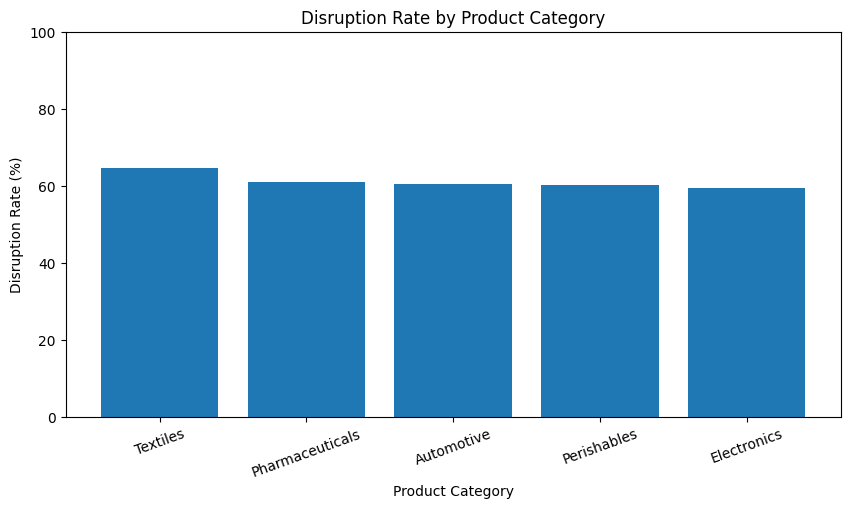

In [59]:
product_disruption_plot = (
    product_analysis.sort_values("Disruption_Rate",ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    product_disruption_plot["Product_Category"],
    product_disruption_plot["Disruption_Rate"]
)

plt.title("Disruption Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.show()

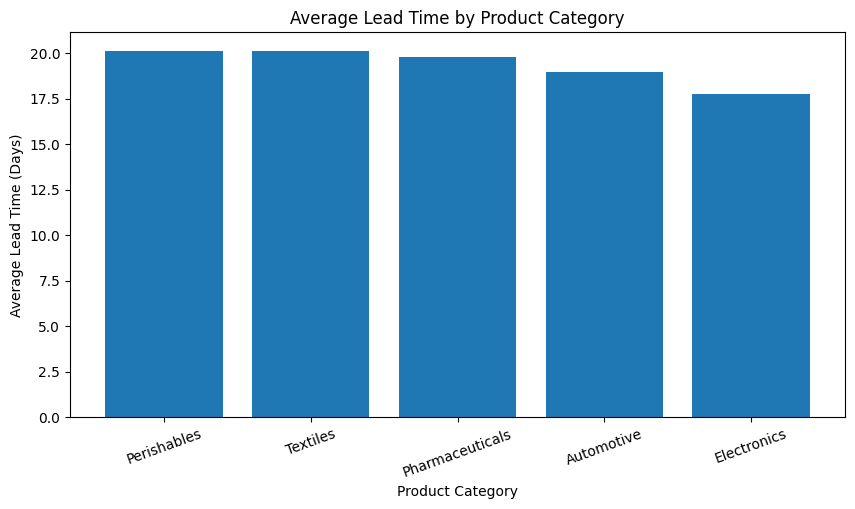

In [60]:
product_leadtime_plot = (
    product_analysis.sort_values("Avg_Lead_Time",ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    product_leadtime_plot["Product_Category"],
    product_leadtime_plot["Avg_Lead_Time"]
)

plt.title("Average Lead Time by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Lead Time (Days)")

plt.xticks(rotation=20)

plt.show()

In [61]:
product_risk_profile = (
    df.groupby("Product_Category")
      .agg(
          Avg_Distance=("Distance_km", "mean"),
          Avg_Geo_Risk=("Geopolitical_Risk_Score","mean"),
          Avg_Carrier_Reliability=("Carrier_Reliability_Score","mean")
      )
      .reset_index()
)

product_risk_profile.round(2)

,Product_Category,Avg_Distance,Avg_Geo_Risk,Avg_Carrier_Reliability
0,Automotive,7723.57,5.17,0.76
1,Electronics,7755.08,5.06,0.76
2,Perishables,7656.78,4.92,0.76
3,Pharmaceuticals,7743.87,5.11,0.75
4,Textiles,7641.81,5.14,0.75


> Product category shows relatively limited variation in both shipment disruption and lead-time performance. Disruption rates range from 59.6% for Electronics to 64.9% for Textiles, while average lead times remain between approximately 17.8 and 20.1 days across all five categories. Compared with factors such as weather and geopolitical risk, product category appears to provide relatively little differentiation in supply chain risk within this dataset.

In [62]:
df["Origin_Port"].value_counts()

Origin_Port
Busan          667
Rotterdam      646
Shanghai       644
Antwerp        635
Dubai          610
Los Angeles    602
Singapore      599
Hamburg        597
Name: count, dtype: int64

In [63]:
origin_analysis = (
    df.groupby("Origin_Port")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

origin_analysis["Disruption_Rate"] *= 100

origin_analysis.sort_values("Disruption_Rate",ascending=False).round(2)

,Origin_Port,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
3,Hamburg,597,62.48,20.07,8.68
6,Shanghai,644,62.42,21.36,9.22
7,Singapore,599,62.27,18.98,7.88
0,Antwerp,635,61.42,18.95,8.31
2,Dubai,610,60.82,17.01,8.06
4,Los Angeles,602,60.30,17.62,7.38
1,Busan,667,60.27,19.61,8.20
5,Rotterdam,646,60.22,21.01,8.50


> Origin port alone does not appear to strongly differentiate disruption risk.

In [64]:
#Which destination ports experience higher disruption rates 
#or longer lead times?
destination_analysis = (
    df.groupby("Destination_Port")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

destination_analysis["Disruption_Rate"] *= 100

destination_analysis.sort_values("Disruption_Rate",ascending=False).round(2)

,Destination_Port,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
8,Singapore,528,63.26,20.83,8.03
5,Marseille,583,62.26,20.76,8.92
1,Busan,570,62.11,21.66,9.12
7,Shanghai,561,61.85,18.57,8.15
0,Antwerp,552,61.41,17.81,8.00
3,Hamburg,536,61.01,19.04,9.07
6,Rotterdam,574,60.63,18.80,7.25
4,Los Angeles,537,59.78,18.89,8.01
2,Dubai,559,59.03,17.79,7.93


> Destination port provides only limited disruption differentiation at the aggregate level.

In [65]:
df["Route"] = (df["Origin_Port"] + " → " + df["Destination_Port"])
df[["Origin_Port", "Destination_Port", "Route"]].head()

,Origin_Port,Destination_Port,Route
0,Singapore,Los Angeles,Singapore → Los Angeles
1,Singapore,Shanghai,Singapore → Shanghai
2,Rotterdam,Los Angeles,Rotterdam → Los Angeles
3,Busan,Hamburg,Busan → Hamburg
4,Busan,Singapore,Busan → Singapore


In [66]:
df["Route"].nunique()

64

In [67]:
route_analysis = (
    df.groupby("Route")
      .agg(
          Shipments=("Shipment_ID", "count"),
          Disruptions=("Disruption_Occurred", "sum"),
          Disruption_Rate=("Disruption_Occurred", "mean"),
          Avg_Lead_Time=("Lead_Time_Days", "mean"),
          Median_Lead_Time=("Lead_Time_Days", "median")
      )
      .reset_index()
)

route_analysis["Disruption_Rate"] *= 100
route_analysis["Shipments"].describe()

count     64.000000
mean      78.125000
std        9.036961
min       57.000000
25%       72.000000
50%       78.000000
75%       85.000000
max      101.000000
Name: Shipments, dtype: float64

In [68]:
#Which trade lanes have the highest observed disruption rates?
route_risk = (
    route_analysis
    .sort_values(["Disruption_Rate", "Shipments"],ascending=[False, False]
    )
)

route_risk.head(10).round(2)

,Route,Shipments,Disruptions,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
45,Rotterdam → Marseille,68,51,75.00,27.76,10.32
39,Los Angeles → Singapore,68,49,72.06,20.74,7.35
29,Hamburg → Rotterdam,72,51,70.83,24.67,13.78
41,Rotterdam → Busan,86,59,68.60,30.37,13.14
14,Busan → Shanghai,91,62,68.13,19.17,11.21
56,Singapore → Antwerp,72,49,68.06,18.34,7.40
55,Shanghai → Singapore,62,42,67.74,23.23,8.54
12,Busan → Marseille,65,44,67.69,28.81,7.76
27,Hamburg → Los Angeles,85,57,67.06,23.89,9.75
53,Shanghai → Marseille,77,51,66.23,26.58,9.19


> Trade-lane segmentation reveals more risk differentiation than analyzing origins or destinations separately.

In [69]:
route_analysis.sort_values("Disruption_Rate").head(10).round(2)

,Route,Shipments,Disruptions,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
11,Busan → Los Angeles,87,42,48.28,16.71,8.54
42,Rotterdam → Dubai,83,41,49.40,20.21,8.90
35,Los Angeles → Hamburg,59,31,52.54,17.19,7.58
37,Los Angeles → Rotterdam,76,41,53.95,15.98,6.27
36,Los Angeles → Marseille,72,39,54.17,13.57,7.65
61,Singapore → Marseille,67,37,55.22,13.87,7.36
5,Antwerp → Rotterdam,97,54,55.67,15.80,5.31
46,Rotterdam → Shanghai,79,44,55.70,20.57,7.15
43,Rotterdam → Hamburg,86,48,55.81,14.75,7.85
31,Hamburg → Singapore,76,43,56.58,19.06,9.32


In [70]:
top_route = df[df["Route"] == "Rotterdam → Marseille"]

top_route["Weather_Condition"].value_counts(normalize=True) * 100

Weather_Condition
Hurricane    30.882353
Storm        23.529412
Rain         17.647059
Fog          17.647059
Clear        10.294118
Name: proportion, dtype: float64

In [71]:
#Which routes have the longest average lead times?
route_analysis.sort_values("Avg_Lead_Time",ascending=False).head(10).round(2)

,Route,Shipments,Disruptions,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
41,Rotterdam → Busan,86,59,68.60,30.37,13.14
12,Busan → Marseille,65,44,67.69,28.81,7.76
45,Rotterdam → Marseille,68,51,75.00,27.76,10.32
25,Hamburg → Busan,72,46,63.89,27.33,13.73
53,Shanghai → Marseille,77,51,66.23,26.58,9.19
6,Antwerp → Shanghai,71,47,66.20,24.91,11.34
29,Hamburg → Rotterdam,72,51,70.83,24.67,13.78
27,Hamburg → Los Angeles,85,57,67.06,23.89,9.75
7,Antwerp → Singapore,79,51,64.56,23.58,7.51
47,Rotterdam → Singapore,76,46,60.53,23.44,7.50


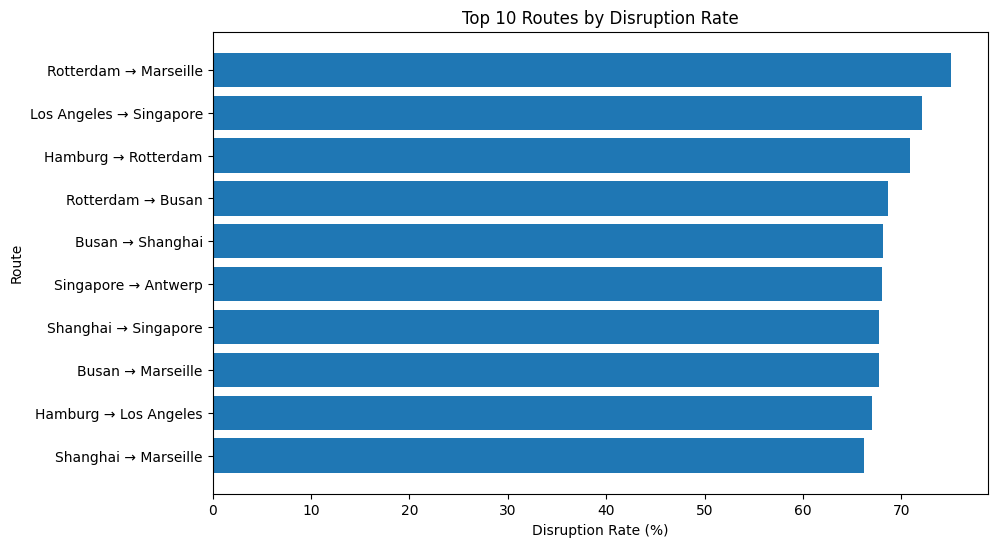

In [72]:
top_routes = (
    route_analysis
    .sort_values("Disruption_Rate",ascending=False).head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_routes["Route"],
    top_routes["Disruption_Rate"]
)

plt.title("Top 10 Routes by Disruption Rate")
plt.xlabel("Disruption Rate (%)")
plt.ylabel("Route")

plt.gca().invert_yaxis()

plt.show()

> Origin and destination ports individually show relatively little variation in disruption rates, with differences of only a few percentage points. However, route-level analysis reveals substantially greater variation, ranging from 48.3% for Busan-Los Angeles to 75.0% for Rotterdam-Marseille. This suggests that **trade-lane segmentation provides more useful operational risk information than analyzing individual ports alone.** Nevertheless, high-risk routes should not automatically be interpreted as causal drivers, as their performance may reflect differences in weather, geopolitical exposure, carrier reliability, or transportation mix.
*For example, 54.4% of Rotterdam-Marseille shipments occur under storm or hurricane conditions, compared with approximately 39.8% across the full dataset, indicating that severe-weather exposure may partly explain the route’s elevated disruption rate.*

In [73]:
df["Fuel_Price_Index"].describe()

count    5000.000000
mean        2.854552
std         0.959533
min         1.200000
25%         2.020000
50%         2.840000
75%         3.710000
max         4.500000
Name: Fuel_Price_Index, dtype: float64

In [74]:
df["Fuel_Price_Quartile"] = pd.qcut(
    df["Fuel_Price_Index"],
    q=4,
    labels=["Q1 Low","Q2","Q3","Q4 High"]
)
df["Fuel_Price_Quartile"].value_counts().sort_index()

Fuel_Price_Quartile
Q1 Low     1261
Q2         1245
Q3         1254
Q4 High    1240
Name: count, dtype: int64

In [75]:
fuel_analysis = (
    df.groupby("Fuel_Price_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Avg_Fuel_Index=("Fuel_Price_Index", "mean"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        P95_Lead_Time=("Lead_Time_Days",lambda x: x.quantile(0.95))
    )
    .reset_index()
)

fuel_analysis["Disruption_Rate"] *= 100

fuel_analysis.round(2)

,Fuel_Price_Quartile,Shipments,Avg_Fuel_Index,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Q1 Low,1261,1.62,61.14,20.19,8.19,85.86
1,Q2,1245,2.44,61.45,19.13,8.65,81.07
2,Q3,1254,3.27,61.56,19.16,8.46,78.90
3,Q4 High,1240,4.11,60.89,18.92,7.82,79.96


> Fuel price does not appear to meaningfully differentiate disruption risk in this dataset.

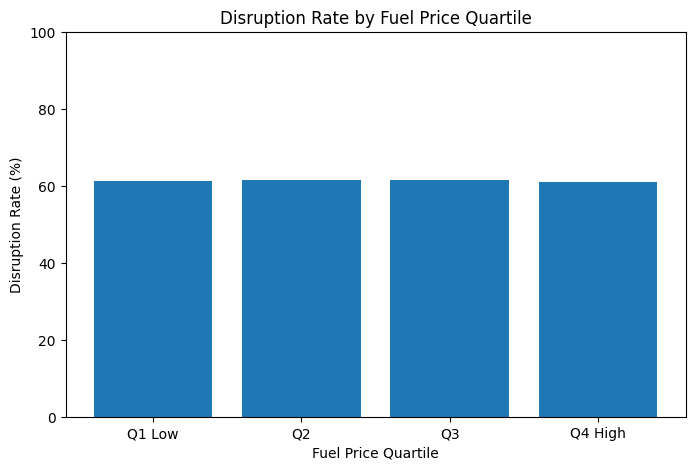

In [76]:
plt.figure(figsize=(8, 5))

plt.bar(
    fuel_analysis["Fuel_Price_Quartile"],
    fuel_analysis["Disruption_Rate"]
)

plt.title("Disruption Rate by Fuel Price Quartile")
plt.xlabel("Fuel Price Quartile")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.show()

In [77]:
df[["Fuel_Price_Index","Lead_Time_Days"]].corr()

,Fuel_Price_Index,Lead_Time_Days
Fuel_Price_Index,1.000000,-0.010256
Lead_Time_Days,-0.010256,1.000000


> Fuel Price Index has virtually no direct linear relationship with Lead Time in this dataset.

In [78]:
df[["Fuel_Price_Index","Disruption_Occurred"]].corr()

,Fuel_Price_Index,Disruption_Occurred
Fuel_Price_Index,1.000000,0.003709
Disruption_Occurred,0.003709,1.000000


In [79]:
df.groupby("Disruption_Occurred")["Fuel_Price_Index"].agg(["mean", "median"])

,mean,median
Disruption_Occurred,,
0,2.850077,2.84
1,2.857382,2.83


> These results suggest that fuel price provides limited explanatory value for the two operational outcomes analyzed in this dataset. However, because transportation cost is not included, the analysis cannot evaluate the potential financial impact of fuel-price fluctuations.

In [80]:
df["Weight_MT"].describe()

count    5000.000000
mean      246.252052
std       142.522591
min         1.030000
25%       124.330000
50%       243.500000
75%       366.955000
max       499.750000
Name: Weight_MT, dtype: float64

In [81]:
df[["Weight_MT", "Lead_Time_Days"]].corr()

,Weight_MT,Lead_Time_Days
Weight_MT,1.000000,-0.005838
Lead_Time_Days,-0.005838,1.000000


In [82]:
df["Weight_Quartile"] = pd.qcut(
    df["Weight_MT"],
    q=4,
    labels=["Q1 Light","Q2","Q3","Q4 Heavy"]
)
df["Weight_Quartile"].value_counts().sort_index()

Weight_Quartile
Q1 Light    1250
Q2          1250
Q3          1250
Q4 Heavy    1250
Name: count, dtype: int64

In [83]:
weight_analysis = (
    df.groupby("Weight_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Avg_Weight=("Weight_MT", "mean"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        P95_Lead_Time=("Lead_Time_Days",lambda x: x.quantile(0.95))
    )
    .reset_index()
)

weight_analysis["Disruption_Rate"] *= 100

weight_analysis.round(2)

,Weight_Quartile,Shipments,Avg_Weight,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time,P95_Lead_Time
0,Q1 Light,1250,62.87,60.24,19.61,8.12,80.10
1,Q2,1250,184.49,60.96,19.69,8.20,85.44
2,Q3,1250,303.52,62.40,18.87,8.18,77.25
3,Q4 Heavy,1250,434.12,61.44,19.25,8.40,80.02


In [84]:
df[["Weight_MT", "Disruption_Occurred"]].corr()

,Weight_MT,Disruption_Occurred
Weight_MT,1.000000,0.012733
Disruption_Occurred,0.012733,1.000000


> Shipment weight has virtually no direct relationship with disruption occurrence in this dataset.

In [85]:
df.groupby("Disruption_Occurred")["Weight_MT"].agg(["mean", "median"])

,mean,median
Disruption_Occurred,,
0,243.970299,240.25
1,247.695002,245.40


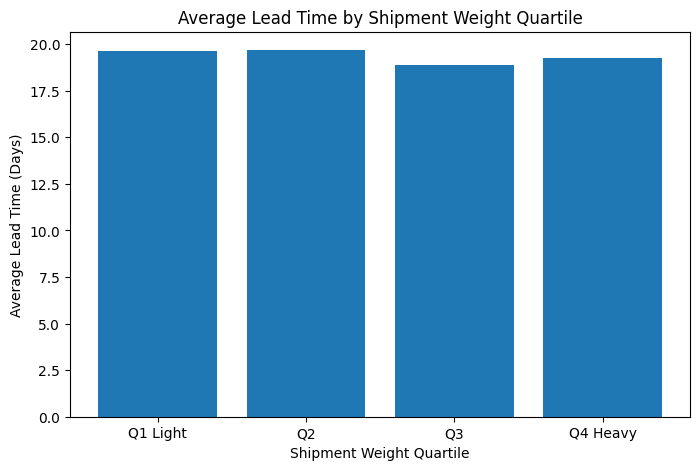

In [86]:
plt.figure(figsize=(8, 5))

plt.bar(
    weight_analysis["Weight_Quartile"],
    weight_analysis["Avg_Lead_Time"]
)

plt.title("Average Lead Time by Shipment Weight Quartile")
plt.xlabel("Shipment Weight Quartile")
plt.ylabel("Average Lead Time (Days)")

plt.show()

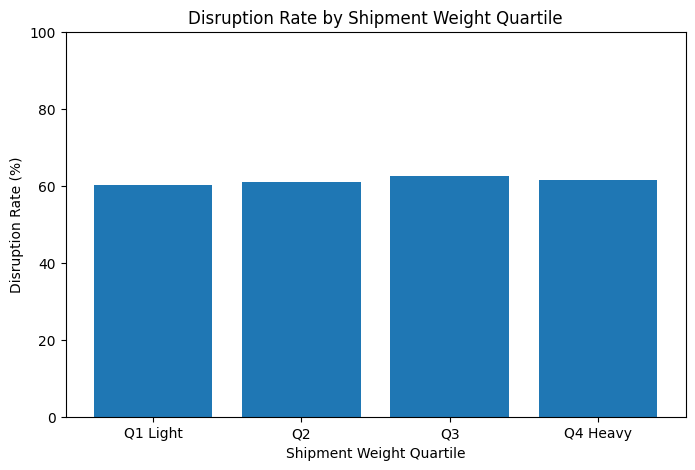

In [87]:
plt.figure(figsize=(8, 5))

plt.bar(
    weight_analysis["Weight_Quartile"],
    weight_analysis["Disruption_Rate"]
)

plt.title("Disruption Rate by Shipment Weight Quartile")
plt.xlabel("Shipment Weight Quartile")
plt.ylabel("Disruption Rate (%)")

plt.ylim(0, 100)

plt.show()

> Shipment weight shows little relationship with either disruption occurrence or lead-time performance. Disruption rates remain between approximately 60% and 62% across all weight quartiles, while average lead times remain close to 19 days. Correlations between weight and both outcomes are also near zero. Therefore, shipment weight provides limited standalone explanatory value for the operational outcomes examined in this dataset.
> However, the dataset does not include freight cost or capacity-utilization measures, where shipment weight may have greater operational relevance.

| Variable                | Disruption            | Lead Time           | Main Role                    |
| ----------------------- | --------------------- | ------------------- | ---------------------------- |
| **Weather**             | **Strong**            | **Strong**          | External risk                |
| **Geopolitical Risk**   | **Strong**            | Weak–Moderate       | External risk                |
| **Carrier Reliability** | **Moderate**          | Very weak           | Operational resilience       |
| **Transport Mode**      | Weak                  | **Strong**          | Transportation duration      |
| **Distance**            | Very weak             | **Moderate–Strong** | Transportation duration      |
| Route                   | Moderate segmentation | Moderate            | Operational risk segment     |
| Product Category        | Weak                  | Weak                | Limited signal               |
| Origin Port             | Weak                  | Weak                | Limited standalone signal    |
| Destination Port        | Weak                  | Weak                | Limited standalone signal    |
| **Fuel Price**          | Very weak             | Very weak           | Limited for current outcomes |
| **Weight**              | Very weak             | Very weak           | Limited for current outcomes |
> Factors associated with disruption are not necessarily the same factors associated with shipment duration.

In [88]:
risk_interaction = (
    df.groupby(["Weather_Condition","Geo_Risk_Quartile"],observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruptions=("Disruption_Occurred", "sum"),
        Disruption_Rate=("Disruption_Occurred", "mean")
    )
    .reset_index()
)

risk_interaction["Disruption_Rate"] *= 100

risk_interaction.round(2)

sample_pivot = risk_interaction.pivot(
    index="Weather_Condition",
    columns="Geo_Risk_Quartile",
    values="Shipments"
)
sample_pivot

Geo_Risk_Quartile,Q1 Low,Q2,Q3,Q4 High
Weather_Condition,,,,
Clear,259,245,256,235
Fog,253,265,262,256
Hurricane,246,257,257,230
Rain,249,223,241,264
Storm,253,265,240,244


In [89]:
risk_pivot = risk_interaction.pivot(
    index="Weather_Condition",
    columns="Geo_Risk_Quartile",
    values="Disruption_Rate"
)
risk_pivot.round(2)

Geo_Risk_Quartile,Q1 Low,Q2,Q3,Q4 High
Weather_Condition,,,,
Clear,19.69,35.92,42.58,51.06
Fog,29.25,41.13,54.58,67.19
Hurricane,100.00,100.00,100.00,100.00
Rain,21.29,37.67,47.30,60.23
Storm,60.47,75.85,87.08,95.90


**Clear + Low Geo Risk = 19.69%**

**Storm + High Geo Risk = 95.90%** --> 95.90 - 19.69 = **+76.21 pp**
- Clear + High Geo Risk  = 51.06% --> 51.06 - 19.69 = +31.37 pp
- Storm + Low Geo Risk = 60.47% --> 60.47 - 19.69 = +40.78 pp
- 31.37 + 40.78 = 72.15 pp


**--> 4.06 percentage points**

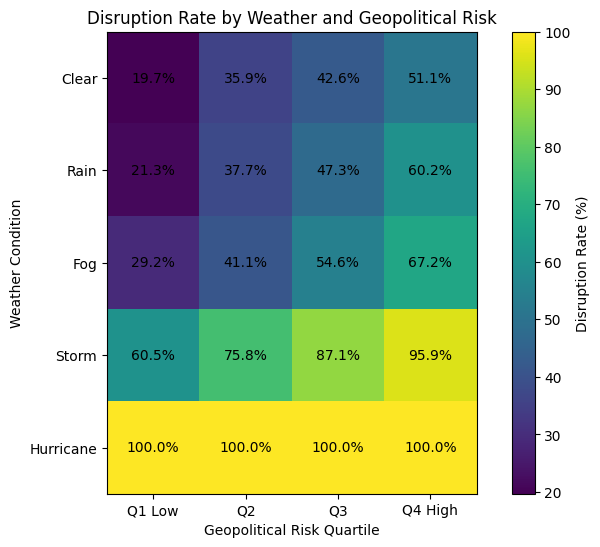

In [90]:
weather_order = ["Clear","Rain","Fog","Storm","Hurricane"]
risk_pivot = risk_pivot.loc[weather_order]

fig, ax = plt.subplots(figsize=(9, 6))
image = ax.imshow(risk_pivot.values)

ax.set_xticks(range(len(risk_pivot.columns)))
ax.set_xticklabels(risk_pivot.columns)

ax.set_yticks(range(len(risk_pivot.index)))
ax.set_yticklabels(risk_pivot.index)

ax.set_xlabel("Geopolitical Risk Quartile")
ax.set_ylabel("Weather Condition")
ax.set_title("Disruption Rate by Weather and Geopolitical Risk")

for i in range(len(risk_pivot.index)):
    for j in range(len(risk_pivot.columns)):
        ax.text(j,i,f"{risk_pivot.iloc[i, j]:.1f}%",
                ha="center",
                va="center"
        )

plt.colorbar(image,label="Disruption Rate (%)")

plt.show()

> Disruption exposure increases along both dimensions of the risk matrix. Under clear weather and low geopolitical risk, only 19.7% of shipments are disrupted. Under storm conditions and high geopolitical risk, the disruption rate rises to 95.9%, indicating a strong compounding-risk pattern.

In [91]:
leadtime_interaction = (
    df.groupby(["Weather_Condition","Geo_Risk_Quartile"],observed=True
              )["Lead_Time_Days"].mean().unstack()
)

leadtime_interaction.loc[weather_order].round(2)

Geo_Risk_Quartile,Q1 Low,Q2,Q3,Q4 High
Weather_Condition,,,,
Clear,6.16,6.35,6.74,7.62
Rain,6.49,7.58,7.83,8.96
Fog,7.53,9.47,10.54,12.01
Storm,14.27,20.27,19.34,23.42
Hurricane,45.31,48.52,52.63,68.80


> The analysis does not reveal a single precise deterministic tipping point outside hurricane conditions, but it does reveal a strong compounding-risk pattern. Under storm conditions, disruption rates rise from 60.5% in the lowest geopolitical-risk quartile to 95.9% in the highest quartile.
> **Shipments facing both storm conditions and geopolitical-risk scores in the highest quartile experience a 95.9% disruption rate, compared with only 19.7% under clear weather and low geopolitical risk.**
| Risk condition                  | Possible response                                  |
| ------------------------------- | -------------------------------------------------- |
| Clear + Low Geo                 | Normal operations                                  |
| Moderate Weather + Moderate Geo | Monitor closely                                    |
| Storm + Moderate/High Geo       | Activate contingency plan                          |
| Storm + High Geo                | Rerouting / alternative carrier / buffer inventory |
| Hurricane                       | Emergency disruption protocol                      |

Disruption_Occurred
- 0 = No disruption
- 1 = Disruption

-> binary classification problem **-> Logistic Regression**.
Bins are useful for storytelling; continuous variables are usually preferable for modeling unless there is a specific reason to categorize them.
**Shipment_ID** is identifier, does not contain business information about shipment risk **-> drop from features**.
Also, **exclude Lead_Time_Days** because of data / target leakage.

In [92]:
features = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Weather_Condition",
    "Carrier_Reliability_Score"
]

X = df[features] #input features

y = df["Disruption_Occurred"] #target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #giữ tỷ lệ classes tương tự
)

categorical_features = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition"
]
numerical_features = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score"
]
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[(
            "cat",
            OneHotEncoder(handle_unknown="ignore",drop="first"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",LogisticRegression(max_iter=2000))
    ]
)
logistic_model.fit(X_train,y_train)
y_pred = logistic_model.predict(X_test) #Class prediction
y_prob = logistic_model.predict_proba(X_test)[:, 1] #Probability prediction

baseline_accuracy = y_test.mean()
baseline_accuracy

np.float64(0.613)

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_prob)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

Accuracy: 0.741
Precision: 0.782
Recall: 0.801
F1 Score: 0.791
ROC-AUC: 0.828


In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[250, 137],
       [122, 491]])

|                | Predicted No | Predicted Yes |
| -------------- | -----------: | ------------: |
| **Actual No**  |          250 |           137 |
| **Actual Yes** |          122 |           491 |
> A baseline logistic regression achieved 74.1% test accuracy and an ROC-AUC of 0.828, outperforming the 61.3% majority-class baseline.

In [95]:
feature_names = (logistic_model.named_steps["preprocessor"].get_feature_names_out())
coefficients = (logistic_model.named_steps["classifier"].coef_[0])

coef_df = pd.DataFrame({"Feature": feature_names,
                        "Coefficient": coefficients})
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])
coef_df["Abs_Coefficient"] = (coef_df["Coefficient"].abs())
coef_df = coef_df.sort_values("Abs_Coefficient",ascending=False)
coef_df.head(15).round(3)

,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
23,cat__Weather_Condition_Hurricane,5.698,298.240,5.698
25,cat__Weather_Condition_Storm,2.022,7.552,2.022
29,num__Geopolitical_Risk_Score,0.677,1.969,0.677
22,cat__Weather_Condition_Fog,0.463,1.588,0.463
8,cat__Destination_Port_Dubai,-0.291,0.747,0.291
10,cat__Destination_Port_Los Angeles,-0.274,0.760,0.274
12,cat__Destination_Port_Rotterdam,-0.211,0.810,0.211
7,cat__Destination_Port_Busan,-0.210,0.811,0.210
30,num__Carrier_Reliability_Score,-0.200,0.819,0.200
21,cat__Product_Category_Textiles,0.128,1.137,0.128


> Holding the other variables constant, Hurricane shipments have dramatically higher estimated disruption odds than Clear-weather shipments.
> LIMITATION: Hurricane coefficient is heavily influenced by the synthetic data-generation structure.

> Holding other features constant, Storm conditions are associated with approximately 7.6 times the odds of disruption compared with Clear conditions.

> Holding other features constant, a one-standard-deviation increase in geopolitical risk is associated with approximately 1.97 times the odds of disruption.

> Holding other variables constant, a one-standard-deviation increase in carrier reliability is associated with approximately 18% lower disruption odds.

> Fuel Price and Weight contributes very little to disruption prediction in the logistic model.

> Distance provides little direct predictive value for disruption after accounting for other features.

> Transport mode matters strongly for lead time, but contributes little to disruption classification.

| Feature                 | Coefficient |       OR | Interpretation          |
| ----------------------- | ----------: | -------: | ----------------------- |
| **Geopolitical Risk**   |  **+0.677** | **1.97** | Strong positive         |
| **Carrier Reliability** |  **-0.200** | **0.82** | Protective relationship |
| Distance                |      -0.030 |     0.97 | Very weak               |
| Fuel Price              |      +0.030 |     1.03 | Very weak               |
| Weight                  |      +0.009 |     1.01 | Almost none             |

| Variable                | EDA                      | Logistic Regression |
| ----------------------- | ------------------------ | ------------------- |
| **Weather**             | Strong                   | **Strong**          |
| **Geopolitical Risk**   | Strong                   | **Strong**          |
| **Carrier Reliability** | Moderate negative        | **Negative**        |
| Transport Mode          | Weak for disruption      | **Weak**            |
| Distance                | Very weak for disruption | **Weak**            |
| Fuel Price              | Very weak                | **Very weak**       |
| Weight                  | Very weak                | **Very weak**       |
| Product Category        | Weak                     | **Weak**            |

> The baseline logistic regression largely confirmed the patterns identified during exploratory analysis. Storm conditions and geopolitical risk emerged as strong predictors of disruption, while higher carrier reliability was associated with lower disruption odds. In contrast, shipment weight, fuel price, distance, transport mode, and product category contributed relatively little to disruption classification. The exceptionally large hurricane coefficient should be interpreted cautiously because all hurricane observations in the simulated dataset are disrupted.

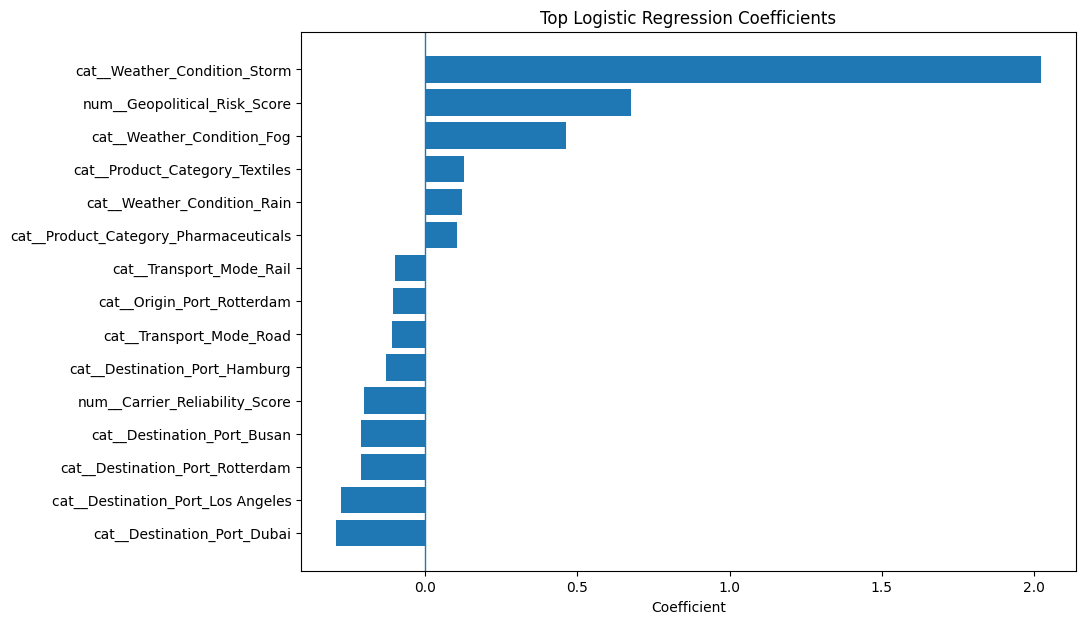

In [96]:
coef_plot = coef_df[~coef_df["Feature"].str.contains("Hurricane")].head(15)

coef_plot = coef_plot.sort_values("Coefficient")

plt.figure(figsize=(10, 7))
plt.barh(coef_plot["Feature"],coef_plot["Coefficient"])
plt.axvline(0,linewidth=1)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")

plt.show()

In [97]:
df_interaction = df.copy()

weather_nonreference = [
    "Fog",
    "Hurricane",
    "Rain",
    "Storm"
]

interaction_features = []

for weather in weather_nonreference:
    column_name = f"GeoRisk_x_{weather}"
    df_interaction[column_name] = (df_interaction["Geopolitical_Risk_Score"] * (df_interaction["Weather_Condition"] == weather)).astype(int)
    interaction_features.append(column_name)

df_interaction[
    [
        "Weather_Condition",
        "Geopolitical_Risk_Score",
        "GeoRisk_x_Fog",
        "GeoRisk_x_Hurricane",
        "GeoRisk_x_Rain",
        "GeoRisk_x_Storm"
    ]
].head(10)

,Weather_Condition,Geopolitical_Risk_Score,GeoRisk_x_Fog,GeoRisk_x_Hurricane,GeoRisk_x_Rain,GeoRisk_x_Storm
0,Hurricane,5.0,0,5,0,0
1,Storm,7.5,0,0,0,7
2,Rain,5.6,0,0,5,0
3,Hurricane,0.8,0,0,0,0
4,Fog,1.9,1,0,0,0
5,Rain,2.2,0,0,2,0
6,Storm,2.6,0,0,0,2
7,Fog,5.7,5,0,0,0
8,Clear,5.0,0,0,0,0
9,Storm,2.0,0,0,0,2


In [98]:
features_interaction = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Weather_Condition",
    "Carrier_Reliability_Score"
] + interaction_features

X_interaction = df_interaction[features_interaction]

y = df_interaction["Disruption_Occurred"]
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_interaction,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
categorical_features = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition"
]
numerical_features_interaction = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score"
] + interaction_features

preprocessor_interaction = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore",drop="first"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features_interaction
        )
    ]
)

interaction_model = Pipeline(
    steps=[
        ("preprocessor",preprocessor_interaction),
        ("classifier",LogisticRegression(max_iter=3000))
    ]
)
interaction_model.fit(X_train_int,y_train_int)

y_pred_int = interaction_model.predict(X_test_int)
y_prob_int = interaction_model.predict_proba(X_test_int)[:, 1]

accuracy_int = accuracy_score(y_test_int,y_pred_int)
precision_int = precision_score(y_test_int,y_pred_int)
recall_int = recall_score(y_test_int,y_pred_int)
f1_int = f1_score(y_test_int,y_pred_int)
roc_auc_int = roc_auc_score(y_test_int,y_prob_int)

print("Accuracy:",round(accuracy_int, 3))
print("Precision:",round(precision_int, 3))
print("Recall:",round(recall_int, 3))
print("F1:",round(f1_int, 3))
print("ROC-AUC:",round(roc_auc_int, 3))

Accuracy: 0.734
Precision: 0.783
Recall: 0.783
F1: 0.783
ROC-AUC: 0.827


| Metric    | Baseline Logistic | Interaction Logistic |
| --------- | ----------------: | -------------------: |
| Accuracy  |         **74.1%** |            **73.1%** |
| Precision |             78.2% |                78.2% |
| Recall    |         **80.1%** |                77.8% |
| F1        |         **79.1%** |                78.0% |
| ROC-AUC   |        **82.85%** |           **82.60%** |

> Adding interaction terms does not improve out-of-sample predictive performance.

In [99]:
train_df = df.loc[X_train.index].copy()

train_no_hurricane = train_df[
    train_df["Weather_Condition"] != "Hurricane"
].copy()

import statsmodels.api as sm
import statsmodels.formula.api as smf

interaction_formula = """
Disruption_Occurred
~
Geopolitical_Risk_Score
* C(Weather_Condition,Treatment(reference="Clear"))
+ Carrier_Reliability_Score
+ Distance_km
+ Weight_MT
+ Fuel_Price_Index
+ C(Transport_Mode)
+ C(Product_Category)
+ C(Origin_Port)
+ C(Destination_Port)
"""
interaction_glm = smf.glm(
    formula=interaction_formula,
    data=train_no_hurricane,
    family=sm.families.Binomial()
).fit()

interaction_results = []
for feature in interaction_glm.params.index:
    if ":" in feature:
        interaction_results.append({
            "Feature": feature,
            "Coefficient": interaction_glm.params[feature],
            "P_Value": interaction_glm.pvalues[feature]
        })
interaction_results = pd.DataFrame(interaction_results)
interaction_results

,Feature,Coefficient,P_Value
0,"Geopolitical_Risk_Score:C(Weather_Condition, T...",0.009029,0.812094
1,"Geopolitical_Risk_Score:C(Weather_Condition, T...",0.070091,0.075233
2,"Geopolitical_Risk_Score:C(Weather_Condition, T...",0.131602,0.004495


| Interaction          | Coefficient |    p-value |
| -------------------- | ----------: | ---------: |
| Geo Risk × Fog       |      +0.009 |  **0.812** |
| Geo Risk × Rain      |      +0.070 |  **0.075** |
| **Geo Risk × Storm** |  **+0.132** | **0.0045** |

> The relationship between geopolitical risk and disruption is stronger under Storm conditions than under Clear conditions.

In [100]:
geo_main = interaction_glm.params["Geopolitical_Risk_Score"]

storm_interaction = interaction_glm.params[
    'Geopolitical_Risk_Score:C(Weather_Condition, Treatment(reference="Clear"))[T.Storm]'
]

clear_geo_odds_ratio = np.exp(geo_main)
storm_geo_odds_ratio = np.exp(geo_main + storm_interaction)
print("Clear:",round(clear_geo_odds_ratio, 3))
print("Storm:",round(storm_geo_odds_ratio, 3))

Clear: 1.217
Storm: 1.388


In [101]:
baseline_formula = """
Disruption_Occurred
~
Geopolitical_Risk_Score
+ C(Weather_Condition,Treatment(reference="Clear"))
+ Carrier_Reliability_Score
+ Distance_km
+ Weight_MT
+ Fuel_Price_Index
+ C(Transport_Mode)
+ C(Product_Category)
+ C(Origin_Port)
+ C(Destination_Port)
"""

baseline_glm = smf.glm(
    formula=baseline_formula,
    data=train_no_hurricane,
    family=sm.families.Binomial()
).fit()

#Likelihood Ratio Test
from scipy.stats import chi2

lr_stat = 2 * (interaction_glm.llf- baseline_glm.llf)
df_difference = (interaction_glm.df_model- baseline_glm.df_model)
lr_p_value = chi2.sf(lr_stat,df_difference)

print("Likelihood Ratio Statistic:",round(lr_stat, 3))
print("Degrees of Freedom:",df_difference)
print("p-value:",round(lr_p_value, 4))

Likelihood Ratio Statistic: 10.916
Degrees of Freedom: 3
p-value: 0.0122


> The weather × geopolitical-risk interaction terms improve statistical model fit relative to a main-effects-only model on the non-hurricane training sample.
>
> The analysis identified a strong compounding-risk pattern rather than a single deterministic tipping point. Under storm conditions, disruption rates increased from 60.5% in the lowest geopolitical-risk quartile to 95.9% in the highest quartile. A logistic regression interaction test further indicated that geopolitical risk has a significantly stronger association with disruption under storm conditions than under clear weather (interaction p ≈ 0.0045).
>
> Hurricane conditions were associated with a 100% disruption rate across all geopolitical-risk levels in the simulated dataset. Because this perfect relationship likely reflects the synthetic data-generation process, hurricane observations were excluded from the formal interaction inference to avoid separation-related instability.

In [102]:
features = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Weather_Condition",
    "Carrier_Reliability_Score"
]
X = df[features]
y = df["Disruption_Occurred"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
categorical_features = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition"
]
numerical_features = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score"
]
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough", #giữ nguyên numerical variables
            numerical_features
        )
    ]
)
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor",rf_preprocessor),
        ("classifier",RandomForestClassifier(n_estimators=500,
                                             random_state=42,
                                             n_jobs=-1)) #sử dụng tất cả CPU cores có sẵn
    ]
)

rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(y_test,rf_pred)
rf_recall = recall_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred)
rf_auc = roc_auc_score(y_test,rf_prob)

print("Accuracy:",round(rf_accuracy, 3))
print("Precision:",round(rf_precision, 3))
print("Recall:",round(rf_recall, 3))
print("F1 Score:",round(rf_f1, 3))
print("ROC-AUC:",round(rf_auc, 3))

Accuracy: 0.724
Precision: 0.772
Recall: 0.78
F1 Score: 0.776
ROC-AUC: 0.812


| Metric    | Logistic Regression |  Random Forest |
| --------- | ------------------: | -------------: |
| Accuracy  |           **0.741** |      **0.724** |
| Precision |           **0.782** |      **0.772** |
| Recall    |           **0.801** |      **0.78** |
| F1        |           **0.791** |      **0.776** |
| ROC-AUC   |           **0.828** |      **0.812** |
> Best model depends partly on business cost of errors, not just highest accuracy.
> The more complex Random Forest model did not outperform the simpler Logistic Regression baseline.

In [103]:
rf_cm = confusion_matrix(y_test,rf_pred)
rf_cm

array([[246, 141],
       [135, 478]])

In [104]:
rf_feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
rf_importances = (
    rf_model
    .named_steps["classifier"]
    .feature_importances_
)
rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
})
rf_importance_df = (rf_importance_df.sort_values("Importance",ascending=False))
rf_importance_df.head(15)

,Feature,Importance
34,num__Geopolitical_Risk_Score,0.131433
28,cat__Weather_Condition_Hurricane,0.110123
35,num__Carrier_Reliability_Score,0.092104
32,num__Weight_MT,0.089304
31,num__Distance_km,0.088823
33,num__Fuel_Price_Index,0.088103
26,cat__Weather_Condition_Clear,0.044294
30,cat__Weather_Condition_Storm,0.036844
29,cat__Weather_Condition_Rain,0.035902
27,cat__Weather_Condition_Fog,0.021821


In [105]:
#permutation importance
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

perm_importance = (perm_importance.sort_values("Importance",ascending=False))
perm_importance

,Feature,Importance,Std
8,Weather_Condition,0.257159,0.015812
7,Geopolitical_Risk_Score,0.049439,0.006422
0,Origin_Port,0.006270,0.002905
9,Carrier_Reliability_Score,0.005916,0.003613
5,Weight_MT,0.003030,0.002253
4,Distance_km,0.000236,0.001611
1,Destination_Port,0.000117,0.002909
6,Fuel_Price_Index,0.000032,0.002216
3,Product_Category,-0.002381,0.001455
2,Transport_Mode,-0.002829,0.001991


> Random Forest relies heavily on Weather for its ability to rank disruption risk.

The high impurity-based importance assigned to Weight appears to be misleading. Permutation importance and exploratory analysis both indicate that shipment weight contributes very little to out-of-sample disruption prediction.

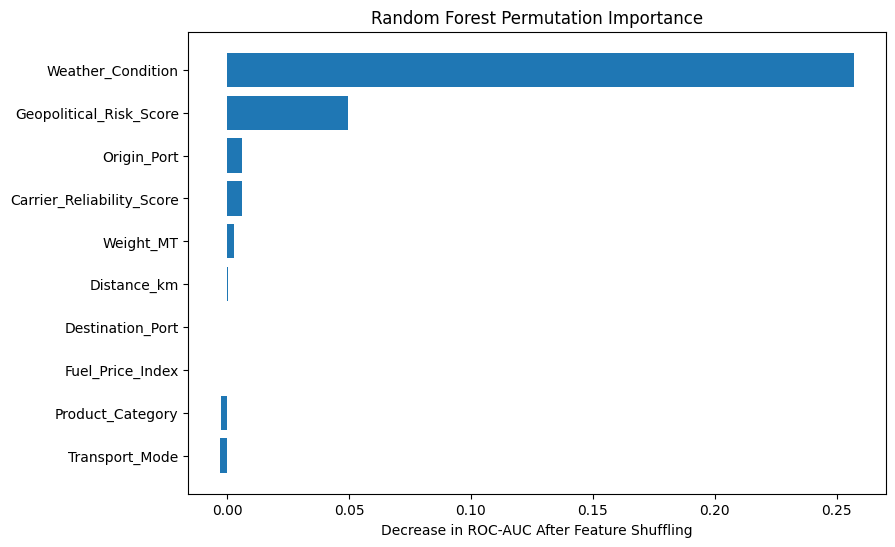

In [106]:
perm_plot = (perm_importance.head(10).sort_values("Importance"))

plt.figure(figsize=(9, 6))
plt.barh(perm_plot["Feature"],perm_plot["Importance"])
plt.title("Random Forest Permutation Importance")
plt.xlabel("Decrease in ROC-AUC After Feature Shuffling")

plt.show()

| Feature                 | EDA       | Logistic Regression     | RF Permutation | Final Assessment for Disruption |
| ----------------------- | --------- | ----------------------- | -------------- | ------------------------------- |
| **Weather**             | Strong    | Strong                  | **Very high**  | **Very important**              |
| **Geo Risk**            | Strong    | Strong                  | **High**       | **Important**                   |
| **Carrier Reliability** | Moderate  | Negative effect         | Positive       | **Moderate**                    |
| Origin                  | Weak      | Some small coefficients | Small          | Low                             |
| Weight                  | Very weak | Very weak               | Near zero      | **Low**                         |
| Distance                | Very weak | Very weak               | Near zero      | **Low**                         |
| Fuel Price              | Very weak | Very weak               | Near zero      | **Low**                         |
| Product                 | Weak      | Weak                    | ~0             | **Low**                         |
| Transport Mode          | Very weak | Weak                    | ~0             | **Low**                         |


In [107]:
rf_train_pred = rf_model.predict(X_train)
rf_train_accuracy = accuracy_score(y_train,rf_train_pred)

print("Train Accuracy:",round(rf_train_accuracy, 3))
print("Test Accuracy:",round(rf_accuracy, 3))

Train Accuracy: 1.0
Test Accuracy: 0.724


In [108]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv_auc = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("RF CV AUC:",rf_cv_auc)
print("RF Mean CV AUC:",round(rf_cv_auc.mean(),3))
print("RF CV Std:",round(rf_cv_auc.std(),3))

RF CV AUC: [0.80000329 0.83467413 0.81531271 0.83818631 0.80573074]
RF Mean CV AUC: 0.819
RF CV Std: 0.015


In [109]:
log_cv_auc = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic CV scores:",log_cv_auc)
print("Logistic Mean CV AUC:",round(log_cv_auc.mean(), 3))
print("Logistic CV Std:",round(log_cv_auc.std(), 3))

Logistic CV scores: [0.81217907 0.84258065 0.82130349 0.84318631 0.81186307]
Logistic Mean CV AUC: 0.826
Logistic CV Std: 0.014


| Fold | Logistic | Random Forest | LR advantage |
| ---- | -------: | ------------: | -----------: |
| 1    |   0.8122 |        0.8000 |      +0.0122 |
| 2    |   0.8426 |        0.8347 |      +0.0079 |
| 3    |   0.8213 |        0.8153 |      +0.0060 |
| 4    |   0.8432 |        0.8382 |      +0.0050 |
| 5    |   0.8119 |        0.8057 |      +0.0061 |

| Model                   |    CV AUC |  Test AUC |
| ----------------------- | --------: | --------: |
| **Logistic Regression** | **0.826** | **0.828** |
| Random Forest           |     0.819 |     0.812 |

> Among the models evaluated so far, Logistic Regression provides the strongest combination of predictive performance, stability, and interpretability.

Một nghiên cứu xuất bản tháng 6/2026 sử dụng chính dataset này cũng nhận thấy Random Forest không phải model tốt nhất; trong setup của họ Gradient Boosting đạt AUC khoảng 0.821, cao hơn RF khoảng 0.806. Điều này là một lời nhắc tốt rằng “more nonlinear” hay “ensemble” không đồng nghĩa tự động tốt hơn. https://www.mdpi.com/2076-3417/16/13/6457

In [110]:
rf_regularized = Pipeline(
    steps=[
        ("preprocessor",rf_preprocessor),
        ("classifier",RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)
rf_reg_cv_auc = cross_val_score(
    rf_regularized,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Regularized RF CV scores:",rf_reg_cv_auc)
print("Regularized RF Mean CV AUC:",round(rf_reg_cv_auc.mean(), 3))
print("Regularized RF CV Std:",round(rf_reg_cv_auc.std(), 3))

Regularized RF CV scores: [0.80764977 0.84004608 0.8197235  0.84257406 0.81203423]
Regularized RF Mean CV AUC: 0.824
Regularized RF CV Std: 0.014


In [111]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Regularized Random Forest"
    ],
    "Mean_CV_AUC": [
        log_cv_auc.mean(),
        rf_cv_auc.mean(),
        rf_reg_cv_auc.mean()
    ],
    "Std_CV_AUC": [
        log_cv_auc.std(),
        rf_cv_auc.std(),
        rf_reg_cv_auc.std()
    ]
})

cv_comparison.round(3)

,Model,Mean_CV_AUC,Std_CV_AUC
0,Logistic Regression,0.826,0.014
1,Random Forest,0.819,0.015
2,Regularized Random Forest,0.824,0.014


In [112]:
rf_regularized.fit(X_train,y_train)
rf_reg_pred = rf_regularized.predict(X_test)
rf_reg_prob = rf_regularized.predict_proba(X_test)[:, 1]

rf_reg_accuracy = accuracy_score(y_test,rf_reg_pred)
rf_reg_precision = precision_score(y_test,rf_reg_pred)
rf_reg_recall = recall_score(y_test,rf_reg_pred)
rf_reg_f1 = f1_score(y_test,rf_reg_pred)
rf_reg_auc = roc_auc_score(y_test,rf_reg_prob)

print("Accuracy:",round(rf_reg_accuracy, 3))
print("Precision:",round(rf_reg_precision, 3))
print("Recall:",round(rf_reg_recall, 3))
print("F1:",round(rf_reg_f1, 3))
print("ROC-AUC:",round(rf_reg_auc, 3))

Accuracy: 0.728
Precision: 0.771
Recall: 0.791
F1: 0.781
ROC-AUC: 0.821


In [113]:
rf_reg_train_pred = rf_regularized.predict(X_train)
rf_reg_train_accuracy = accuracy_score(y_train,rf_reg_train_pred)
print("Train Accuracy:",round(rf_reg_train_accuracy, 3))
print("Test Accuracy:",round(rf_reg_accuracy, 3))

Train Accuracy: 0.833
Test Accuracy: 0.728


In [114]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","Regularized Random Forest"],
    "Accuracy": [0.741,0.724,rf_reg_accuracy],
    "Precision": [0.782,0.772,rf_reg_precision],
    "Recall": [0.801,0.780,rf_reg_recall],
    "F1": [0.791,0.776,rf_reg_f1],
    "ROC_AUC": [0.828,0.812,rf_reg_auc],
    "CV_AUC": [0.826,0.819,0.824]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_AUC
0,Logistic Regression,0.741,0.782,0.801,0.791,0.828,0.826
1,Random Forest,0.724,0.772,0.780,0.776,0.812,0.819
2,Regularized Random Forest,0.728,0.771,0.791,0.781,0.821,0.824


> Logistic Regression was selected as the preferred disruption-classification model. It achieved the highest test ROC-AUC (0.828) and five-fold cross-validation ROC-AUC (0.826), while also outperforming both Random Forest variants in accuracy, recall, and F1 score. Although regularization improved Random Forest generalization, the simpler logistic model still provided the strongest balance of predictive performance and business interpretability.

In [115]:
regression_features = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Weather_Condition",
    "Carrier_Reliability_Score"
]
X_reg = df[regression_features]
y_reg = df["Lead_Time_Days"]

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

from sklearn.dummy import DummyRegressor

dummy_reg = DummyRegressor(strategy="median")
dummy_reg.fit(X_train_reg,y_train_reg)
dummy_pred = dummy_reg.predict(X_test_reg)

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

def evaluate_regression(y_true,y_pred,model_name):
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    r2 = r2_score(y_true,y_pred)
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

dummy_results = evaluate_regression(y_test_reg,dummy_pred,"Median Baseline")
dummy_results

{'Model': 'Median Baseline',
 'MAE': 15.44539,
 'RMSE': np.float64(31.72953432056638),
 'R2': -0.11515173356237818}

In [116]:
categorical_features_reg = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition"
]
numerical_features_reg = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score"
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore",drop="first"),
        categorical_features_reg
        ),("num",StandardScaler(),numerical_features_reg)
    ]
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_reg = Pipeline(
    steps=[
        ("preprocessor",reg_preprocessor),
        ("regressor",LinearRegression())
    ]
)
linear_reg.fit(X_train_reg,y_train_reg)
linear_pred = linear_reg.predict(X_test_reg)
linear_results = evaluate_regression(y_test_reg,linear_pred,"Linear Regression - Raw Target")
linear_results

{'Model': 'Linear Regression - Raw Target',
 'MAE': 12.067100116196624,
 'RMSE': np.float64(18.669124194623752),
 'R2': 0.6139403104806049}

In [117]:
from sklearn.compose import TransformedTargetRegressor

log_linear_reg = Pipeline(
    steps=[
        ("preprocessor",reg_preprocessor),
        ("regressor",TransformedTargetRegressor(
                regressor=LinearRegression(),
                func=np.log1p,
                inverse_func=np.expm1
            )
        )
    ]
)
log_linear_reg.fit(X_train_reg,y_train_reg)
log_linear_pred = log_linear_reg.predict(X_test_reg)
log_linear_results = evaluate_regression(
    y_test_reg,
    log_linear_pred,
    "Linear Regression - Log Target"
)
log_linear_results

{'Model': 'Linear Regression - Log Target',
 'MAE': 3.985780113062291,
 'RMSE': np.float64(8.773884014335188),
 'R2': 0.9147311618582592}

In [118]:
regression_comparison = pd.DataFrame([
    dummy_results,
    linear_results,
    log_linear_results
])
regression_comparison.round(3)

,Model,MAE,RMSE,R2
0,Median Baseline,15.445,31.730,-0.115
1,Linear Regression - Raw Target,12.067,18.669,0.614
2,Linear Regression - Log Target,3.986,8.774,0.915


In [119]:
print("Raw Linear negative predictions:",(linear_pred < 0).sum())
print("Minimum raw prediction:",linear_pred.min())
print("Log model negative predictions:",(log_linear_pred < 0).sum())

Raw Linear negative predictions: 238
Minimum raw prediction: -30.022402992420105
Log model negative predictions: 50


In [120]:
log_linear_pred_clipped = np.clip(
    log_linear_pred,
    a_min=0,
    a_max=None
)
log_clipped_results = evaluate_regression(
    y_test_reg,
    log_linear_pred_clipped,
    "Log Linear - Clipped at 0"
)
pd.DataFrame([log_linear_results,log_clipped_results]).round(3)

,Model,MAE,RMSE,R2
0,Linear Regression - Log Target,3.986,8.774,0.915
1,Log Linear - Clipped at 0,3.974,8.773,0.915


In [121]:
negative_log_preds = log_linear_pred[log_linear_pred < 0]
pd.Series(negative_log_preds).describe()

count    50.000000
mean     -0.242023
std       0.121467
min      -0.479177
25%      -0.328477
50%      -0.233189
75%      -0.148611
max      -0.014890
dtype: float64

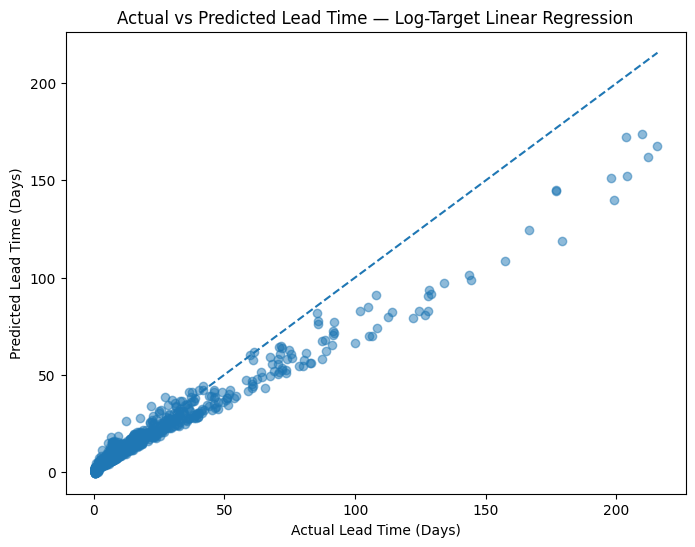

In [122]:
prediction_analysis = pd.DataFrame({
    "Actual": y_test_reg.values,
    "Predicted": log_linear_pred
})
prediction_analysis["Residual"] = (
    prediction_analysis["Actual"] - prediction_analysis["Predicted"]
)
prediction_analysis["Absolute_Error"] = (prediction_analysis["Residual"].abs())

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_analysis["Actual"],
    prediction_analysis["Predicted"],
    alpha=0.5
)

max_value = max(
    prediction_analysis["Actual"].max(),
    prediction_analysis["Predicted"].max()
)

plt.plot([0, max_value],[0, max_value],linestyle="--")

plt.xlabel("Actual Lead Time (Days)")
plt.ylabel("Predicted Lead Time (Days)")
plt.title("Actual vs Predicted Lead Time — Log-Target Linear Regression")

plt.show()

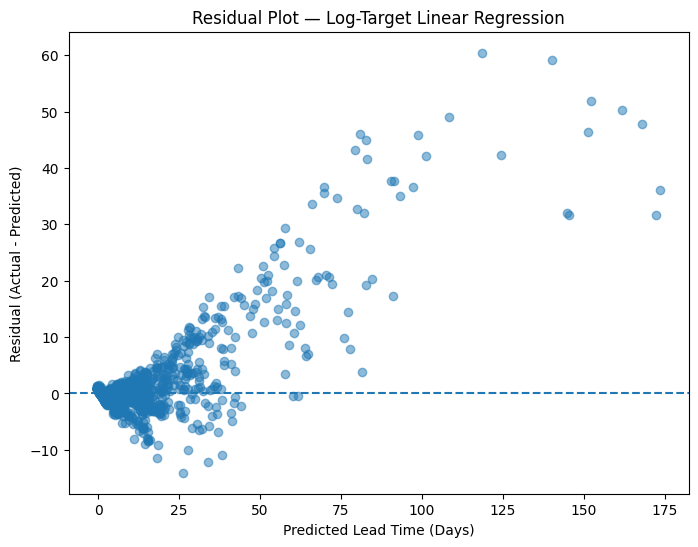

In [123]:
plt.figure(figsize=(8, 6))

plt.scatter(
    log_linear_pred,
    prediction_analysis["Residual"],
    alpha=0.5
)
plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted Lead Time (Days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Log-Target Linear Regression")

plt.show()

In [124]:
p95_threshold = y_train_reg.quantile(0.95)
print("Training P95 threshold:",round(p95_threshold, 2))
extreme_mask = (y_test_reg >= p95_threshold)
extreme_actual = y_test_reg[extreme_mask]
extreme_pred = log_linear_pred[extreme_mask]
extreme_mae = mean_absolute_error(extreme_actual,extreme_pred)
extreme_rmse = np.sqrt(mean_squared_error(extreme_actual,extreme_pred))

print("Extreme shipments:",extreme_mask.sum())
print("Extreme MAE:",round(extreme_mae, 2))
print("Extreme RMSE:",round(extreme_rmse, 2))
print("Actual extreme mean:",round(extreme_actual.mean(), 2))
print("Predicted extreme mean:",round(extreme_pred.mean(), 2))

Training P95 threshold: 81.32
Extreme shipments: 45
Extreme MAE: 32.99
Extreme RMSE: 35.46
Actual extreme mean: 128.93
Predicted extreme mean: 95.94


> For shipments in the extreme-delay tail, the model underestimates lead time by approximately 33 days on average, or about 26% of their actual mean lead time.

In [125]:
prediction_analysis["Lead_Time_Band"] = pd.cut(
    prediction_analysis["Actual"],
    bins=[-np.inf,10,30,80,np.inf],
    labels=[
        "≤10 days",
        "10-30 days",
        "30-80 days",
        ">80 days"
    ]
)
band_performance = (
    prediction_analysis
    .groupby("Lead_Time_Band",observed=True)
    .agg(
        Shipments=("Actual", "count"),
        Avg_Actual=("Actual", "mean"),
        Avg_Predicted=("Predicted", "mean"),
        MAE=("Absolute_Error", "mean")
    )
)
band_performance.round(2)

,Shipments,Avg_Actual,Avg_Predicted,MAE
Lead_Time_Band,,,,
≤10 days,570,3.77,4.47,1.25
10-30 days,256,17.22,16.78,2.32
30-80 days,126,46.60,38.23,8.94
>80 days,48,125.90,93.55,32.35


In [126]:
from sklearn.model_selection import (KFold,cross_validate)

reg_cv = KFold(n_splits=5,shuffle=True,random_state=42)
raw_cv = cross_validate(
    linear_reg,
    X_train_reg,
    y_train_reg,
    cv=reg_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)
raw_cv_mae = -raw_cv["test_MAE"]
raw_cv_rmse = -raw_cv["test_RMSE"]
raw_cv_r2 = raw_cv["test_R2"]

log_cv = cross_validate(
    log_linear_reg,
    X_train_reg,
    y_train_reg,
    cv=reg_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)
log_cv_mae = -log_cv["test_MAE"]
log_cv_rmse = -log_cv["test_RMSE"]
log_cv_r2 = log_cv["test_R2"]

reg_cv_comparison = pd.DataFrame({
    "Model": ["Linear Regression - Raw","Linear Regression - Log Target"],
    "CV_MAE_Mean": [raw_cv_mae.mean(),log_cv_mae.mean()],
    "CV_MAE_Std": [raw_cv_mae.std(),log_cv_mae.std()],
    "CV_RMSE_Mean": [raw_cv_rmse.mean(),log_cv_rmse.mean()],
    "CV_RMSE_Std": [raw_cv_rmse.std(),log_cv_rmse.std()],
    "CV_R2_Mean": [raw_cv_r2.mean(),log_cv_r2.mean()],
    "CV_R2_Std": [raw_cv_r2.std(),log_cv_r2.std()]
})
reg_cv_comparison.round(3)

,Model,CV_MAE_Mean,CV_MAE_Std,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std
0,Linear Regression - Raw,12.408,0.254,19.526,1.017,0.619,0.011
1,Linear Regression - Log Target,4.194,0.286,9.219,0.776,0.915,0.005


> Log-transforming lead time produces a substantially more stable and accurate linear model than modeling raw lead time directly.
>
> Log-transforming the target dramatically improved linear-regression performance. Five-fold cross-validation produced an average MAE of 4.19 days and R² of 0.915, closely matching the holdout-test results. However, model accuracy deteriorated as actual lead times increased. For shipments above the 95th-percentile lead-time threshold, MAE rose to approximately 33 days, and predicted lead time averaged 95.9 days compared with an actual average of 128.9 days. This indicates systematic underestimation of extreme shipment delays despite strong overall predictive performance.

In [127]:
rf_reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_reg
        ),
        ("num","passthrough",numerical_features_reg)
    ]
)
from sklearn.ensemble import RandomForestRegressor

rf_regressor = Pipeline(
    steps=[
        ("preprocessor",rf_reg_preprocessor),
        ("regressor",RandomForestRegressor(
                n_estimators=500,
                max_depth=12,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)
rf_reg_cv = cross_validate(
    rf_regressor,
    X_train_reg,
    y_train_reg,
    cv=reg_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)
rf_reg_cv_mae = -rf_reg_cv["test_MAE"]
rf_reg_cv_rmse = -rf_reg_cv["test_RMSE"]
rf_reg_cv_r2 = rf_reg_cv["test_R2"]

reg_model_cv_comparison = pd.DataFrame({
    "Model": ["Linear Regression - Raw","Linear Regression - Log Target","Random Forest Regressor"],
    "CV_MAE_Mean": [raw_cv_mae.mean(),log_cv_mae.mean(),rf_reg_cv_mae.mean()],
    "CV_RMSE_Mean": [raw_cv_rmse.mean(),log_cv_rmse.mean(),rf_reg_cv_rmse.mean()],
    "CV_R2_Mean": [raw_cv_r2.mean(),log_cv_r2.mean(),rf_reg_cv_r2.mean()],
    "CV_R2_Std": [raw_cv_r2.std(),log_cv_r2.std(),rf_reg_cv_r2.std()]
})
reg_model_cv_comparison.round(3)

,Model,CV_MAE_Mean,CV_RMSE_Mean,CV_R2_Mean,CV_R2_Std
0,Linear Regression - Raw,12.408,19.526,0.619,0.011
1,Linear Regression - Log Target,4.194,9.219,0.915,0.005
2,Random Forest Regressor,4.719,10.046,0.899,0.009


In [128]:
rf_regressor.fit(X_train_reg,y_train_reg)
rf_reg_pred = rf_regressor.predict(X_test_reg)
rf_reg_results = evaluate_regression(y_test_reg,rf_reg_pred,"Random Forest Regressor")
rf_reg_results

{'Model': 'Random Forest Regressor',
 'MAE': 4.082754621725489,
 'RMSE': np.float64(8.48642707297699),
 'R2': 0.9202269247396744}

In [129]:
final_reg_comparison = pd.DataFrame([
    dummy_results,
    linear_results,
    log_linear_results,
    rf_reg_results
])
final_reg_comparison.round(3)

,Model,MAE,RMSE,R2
0,Median Baseline,15.445,31.730,-0.115
1,Linear Regression - Raw Target,12.067,18.669,0.614
2,Linear Regression - Log Target,3.986,8.774,0.915
3,Random Forest Regressor,4.083,8.486,0.920


In [130]:
rf_extreme_pred = rf_reg_pred[extreme_mask]
rf_extreme_mae = mean_absolute_error(extreme_actual,rf_extreme_pred)
rf_extreme_rmse = np.sqrt(mean_squared_error(extreme_actual,rf_extreme_pred))

print("Extreme shipments:",extreme_mask.sum())
print("RF Extreme MAE:",round(rf_extreme_mae, 2))
print("RF Extreme RMSE:",round(rf_extreme_rmse, 2))
print("Actual Extreme Mean:",round(extreme_actual.mean(), 2))
print("RF Predicted Extreme Mean:",round(rf_extreme_pred.mean(), 2))

Extreme shipments: 45
RF Extreme MAE: 27.0
RF Extreme RMSE: 33.22
Actual Extreme Mean: 128.93
RF Predicted Extreme Mean: 101.92


In [131]:
extreme_comparison = pd.DataFrame({
    "Model": ["Log-Target Linear Regression","Random Forest Regressor"],
    "Extreme_MAE": [extreme_mae,rf_extreme_mae],
    "Extreme_RMSE": [extreme_rmse,rf_extreme_rmse],
    "Predicted_Extreme_Mean": [extreme_pred.mean(),rf_extreme_pred.mean()]
})
extreme_comparison["Actual_Extreme_Mean"] = (extreme_actual.mean())
extreme_comparison.round(2)

,Model,Extreme_MAE,Extreme_RMSE,Predicted_Extreme_Mean,Actual_Extreme_Mean
0,Log-Target Linear Regression,32.99,35.46,95.94,128.93
1,Random Forest Regressor,27.00,33.22,101.92,128.93


Random Forest reduces, but does not eliminate, the systematic underestimation of extreme delays.
> The log-target linear model was selected as the primary lead-time forecasting model because it achieved the strongest overall cross-validation performance (MAE 4.19 days, RMSE 9.22 days, R² 0.915). However, performance deteriorated substantially for extreme delays. Random Forest reduced extreme-delay MAE from 33.0 to 27.0 days, but both models continued to systematically underestimate the longest lead times.

In [132]:
preprocessor_fitted = (log_linear_reg.named_steps["preprocessor"])
ttr_fitted = (log_linear_reg.named_steps["regressor"])
X_train_transformed = (preprocessor_fitted.transform(X_train_reg))
train_log_pred = (ttr_fitted.regressor_.predict(X_train_transformed))
train_log_actual = np.log1p(y_train_reg.to_numpy())
train_log_residuals = (train_log_actual - train_log_pred)
smearing_factor = np.mean(np.exp(train_log_residuals))
print("Smearing Factor:",round(smearing_factor, 4))

Smearing Factor: 1.0553


In [133]:
X_test_transformed = (preprocessor_fitted.transform(X_test_reg))
test_log_pred = (ttr_fitted.regressor_.predict(X_test_transformed))
smearing_pred = (np.exp(test_log_pred) * smearing_factor - 1)
smearing_pred = np.clip(smearing_pred,0,None)
smearing_results = evaluate_regression(y_test_reg,smearing_pred,"Log Linear + Smearing")
pd.DataFrame([log_linear_results,smearing_results]).round(3)

,Model,MAE,RMSE,R2
0,Linear Regression - Log Target,3.986,8.774,0.915
1,Log Linear + Smearing,3.603,7.579,0.936


In [134]:
smearing_extreme_pred = smearing_pred[extreme_mask]
smearing_extreme_mae = mean_absolute_error(extreme_actual,smearing_extreme_pred)
smearing_extreme_rmse = np.sqrt(mean_squared_error(extreme_actual,smearing_extreme_pred))
tail_comparison = pd.DataFrame({
    "Model": ["Log-Target Linear","Log Linear + Smearing","Random Forest"],
    "Extreme_MAE": [extreme_mae,smearing_extreme_mae,rf_extreme_mae],
    "Extreme_RMSE": [extreme_rmse,smearing_extreme_rmse,rf_extreme_rmse],
    "Predicted_Extreme_Mean": [extreme_pred.mean(),smearing_extreme_pred.mean(),rf_extreme_pred.mean()]
})

tail_comparison["Actual_Extreme_Mean"] = extreme_actual.mean()
tail_comparison.round(2)

,Model,Extreme_MAE,Extreme_RMSE,Predicted_Extreme_Mean,Actual_Extreme_Mean
0,Log-Target Linear,32.99,35.46,95.94,128.93
1,Log Linear + Smearing,27.66,30.18,101.30,128.93
2,Random Forest,27.00,33.22,101.92,128.93


In [135]:
smearing_results = evaluate_regression(y_test_reg,smearing_pred,"Log Linear + Smearing")
smearing_results

{'Model': 'Log Linear + Smearing',
 'MAE': 3.6026468950557904,
 'RMSE': np.float64(7.5786536099652535),
 'R2': 0.936380436838618}

In [136]:
overall_regression_comparison = pd.DataFrame([
    dummy_results,
    linear_results,
    log_linear_results,
    smearing_results,
    rf_reg_results
])
overall_regression_comparison.round(3)

,Model,MAE,RMSE,R2
0,Median Baseline,15.445,31.730,-0.115
1,Linear Regression - Raw Target,12.067,18.669,0.614
2,Linear Regression - Log Target,3.986,8.774,0.915
3,Log Linear + Smearing,3.603,7.579,0.936
4,Random Forest Regressor,4.083,8.486,0.920


In [137]:
smearing_analysis = pd.DataFrame({
    "Actual": y_test_reg.values,
    "Predicted": smearing_pred
})

smearing_analysis["Absolute_Error"] = (
    smearing_analysis["Actual"] - smearing_analysis["Predicted"]
).abs()

smearing_analysis["Lead_Time_Band"] = pd.cut(
    smearing_analysis["Actual"],
    bins=[-np.inf,10,30,80,np.inf],
    labels=[
        "≤10 days",
        "10-30 days",
        "30-80 days",
        ">80 days"
    ]
)

smearing_band_performance = (
    smearing_analysis.groupby("Lead_Time_Band",observed=True)
    .agg(
        Shipments=("Actual", "count"),
        Avg_Actual=("Actual", "mean"),
        Avg_Predicted=("Predicted", "mean"),
        MAE=("Absolute_Error", "mean")
    )
)
smearing_band_performance.round(2)

,Shipments,Avg_Actual,Avg_Predicted,MAE
Lead_Time_Band,,,,
≤10 days,570,3.77,4.79,1.37
10-30 days,256,17.22,17.76,2.27
30-80 days,126,46.60,40.40,7.44
>80 days,48,125.90,98.78,27.15


| Band       |   Before | After Smearing |
| ---------- | -------: | -------------: |
| ≤10 days   | **1.25** |           1.37 |
| 10-30 days |     2.32 |       **2.27** |
| 30-80 days |     8.94 |       **7.44** |
| >80 days   |    32.35 |      **27.15** |
> A log-transformed linear regression was selected for lead-time forecasting because it substantially outperformed raw linear regression and Random Forest in cross-validation. Applying Duan's smearing correction further improved holdout performance to an MAE of 3.60 days, RMSE of 7.58 days, and R² of 0.936. The correction also reduced extreme-delay MAE from approximately 33.0 to 27.7 days. However, shipments above the 95th-percentile lead-time threshold remained systematically underestimated, indicating that extreme delays should still be treated as a separate operational risk.

In [138]:
feature_names_reg = (
    log_linear_reg.named_steps["preprocessor"].get_feature_names_out()
)
fitted_ttr = (log_linear_reg.named_steps["regressor"])
reg_coefficients = (fitted_ttr.regressor_.coef_)

leadtime_coef_df = pd.DataFrame({
    "Feature": feature_names_reg,
    "Coefficient": reg_coefficients
})

leadtime_coef_df["Percent_Effect"] = (
    np.exp(leadtime_coef_df["Coefficient"]) - 1
) * 100

leadtime_coef_df["Abs_Coefficient"] = (
    leadtime_coef_df["Coefficient"].abs()
)

leadtime_coef_df = (
    leadtime_coef_df.sort_values("Abs_Coefficient",ascending=False)
)

leadtime_coef_df.head(20).round(3)

,Feature,Coefficient,Percent_Effect,Abs_Coefficient
17,cat__Transport_Mode_Sea,2.365,964.224,2.365
15,cat__Transport_Mode_Rail,1.750,475.681,1.750
23,cat__Weather_Condition_Hurricane,1.675,433.745,1.675
16,cat__Transport_Mode_Road,1.602,396.503,1.602
25,cat__Weather_Condition_Storm,0.828,128.968,0.828
26,num__Distance_km,0.520,68.159,0.520
22,cat__Weather_Condition_Fog,0.278,32.110,0.278
24,cat__Weather_Condition_Rain,0.127,13.551,0.127
29,num__Geopolitical_Risk_Score,0.083,8.669,0.083
3,cat__Origin_Port_Los Angeles,-0.065,-6.280,0.065


| Factor                  | Disruption model   | Lead-time model    |
| ----------------------- | ------------------ | ------------------ |
| **Weather**             | Very important     | **Very important** |
| **Geo Risk**            | **Very important** | Smaller            |
| **Carrier Reliability** | Moderate           | Likely small       |
| **Transport Mode**      | Weak               | **Very important** |
| **Distance**            | Weak               | **Important**      |

> Lead-time performance is primarily driven by transportation mode, weather severity, and shipment distance. After controlling for other shipment characteristics, sea, rail, and road transport are associated with substantially longer predicted lead times than the reference mode, while increasingly severe weather conditions show a clear escalation in predicted duration. Distance remains an important positive driver even after controlling for transport mode. By contrast, geopolitical risk has a smaller direct relationship with lead time, despite being one of the strongest predictors of shipment disruption.

In [139]:
encoder = (
    log_linear_reg.named_steps["preprocessor"].named_transformers_["cat"]
)

for feature, categories in zip(categorical_features_reg,encoder.categories_):
    print(feature,"→ reference:",categories[0])

Origin_Port → reference: Antwerp
Destination_Port → reference: Antwerp
Transport_Mode → reference: Air
Product_Category → reference: Automotive
Weather_Condition → reference: Clear


In [140]:
scaler = (
    log_linear_reg.named_steps["preprocessor"].named_transformers_["num"]
)

numeric_scale_df = pd.DataFrame({
    "Feature": numerical_features_reg,
    "Mean": scaler.mean_,
    "Std_Dev": scaler.scale_
})

numeric_scale_df.round(3)

,Feature,Mean,Std_Dev
0,Distance_km,7722.635,4205.039
1,Weight_MT,246.779,142.507
2,Fuel_Price_Index,2.844,0.955
3,Geopolitical_Risk_Score,5.076,2.872
4,Carrier_Reliability_Score,0.755,0.144


In [141]:
distance_beta = 0.520
distance_sd = 4205.039

beta_per_1000km = (distance_beta * 1000 / distance_sd)
distance_effect_1000km = (np.exp(beta_per_1000km) - 1) * 100
print(round(distance_effect_1000km, 2))

13.16


> Each additional 1,000 km of shipment distance is associated with approximately 13% higher predicted (Lead Time + 1), holding transport mode and the other included variables constant.

In [142]:
geo_beta = 0.083
geo_sd = 2.872

beta_per_geo_point = (geo_beta / geo_sd)
geo_effect_per_point = (np.exp(beta_per_geo_point) - 1) * 100
print(round(geo_effect_per_point, 2))

2.93


> Each one-point increase in geopolitical risk score is associated with approximately 2.9% higher predicted (Lead Time + 1), holding the other variables constant.

                **DISRUPTION**

Weather              ████████████████████

Geopolitical Risk    ███████████

Carrier Reliability  ███

Route                 segmentation value

Distance             ~

Weight               ~

Fuel Price           ~

Transport Mode       ~

Product              ~
> Weather and geopolitical risk dominate disruption exposure, while carrier reliability provides a smaller but meaningful resilience signal.

                 **LEAD TIME**

Transport Mode       ████████████████████

Weather              █████████████████

Distance             ███████████

Geo Risk             ██


Ports                ~

Product              ~

Weight               ~

Fuel Price           ~

Carrier Reliability  ~
> Transport mode, weather severity and distance are the primary drivers of shipment duration.

> Variables associated with disruption occurrence are not identical to those driving transportation duration. Geopolitical risk is particularly important for disruption prediction, whereas transport mode and distance primarily explain lead-time performance.

| Finding                                                   | Business Risk                | Recommendation                                   | KPI                        |
| --------------------------------------------------------- | ---------------------------- | ------------------------------------------------ | -------------------------- |
| Storm + high Geo Risk → 95.9% disruption                  | Compound risk                | Risk escalation matrix                           | Recall, alert precision    |
| Carrier reliability negatively associated with disruption | Carrier vulnerability        | Prefer reliable carriers for high-risk shipments | Disruption by carrier tier |
| Mode + Distance + Weather drive LT                        | Static ETA inaccurate        | Dynamic ETA forecasting                          | MAE, RMSE                  |
| Extreme delays underpredicted                             | Planning failure in tail     | Manual review + safety buffer                    | P95 MAE                    |
| Routes show heterogeneous risk                            | Wrong root-cause attribution | Route drill-down analysis                        | Route-adjusted disruption  |
| Fuel/Weight weak for current targets                      | Dashboard noise              | De-prioritize for disruption monitoring          | Permutation importance     |